In [1]:
import pandas as pd

email_batch_1 = pd.read_csv('C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/Model Building/A_Dataset/Category/synthetic_emails_50k_batch1.csv')
email_batch_2 = pd.read_csv('C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/Model Building/A_Dataset/Category/synthetic_emails_50k_batch2.csv')
email_batch_3 = pd.read_csv('C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/Model Building/A_Dataset/Category/synthetic_emails_50k_batch3.csv')
email_batch_4 = pd.read_csv('C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/Model Building/A_Dataset/Category/synthetic_emails_50k_batch4.csv')
email_batch_5 = pd.read_csv('C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/Model Building/A_Dataset/Category/synthetic_emails_50k_batch5.csv')
email_batch_6 = pd.read_csv('C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/Model Building/A_Dataset/Category/synthetic_emails_50k_batch6.csv')
email_batch_7 = pd.read_csv('C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/Model Building/A_Dataset/Category/synthetic_emails_50k_batch7.csv')
email_batch_8 = pd.read_csv('C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/Model Building/A_Dataset/Category/synthetic_emails_50k_batch8.csv')
email_batch_9 = pd.read_csv('C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/Model Building/A_Dataset/Category/synthetic_emails_50k_batch9.csv')
email_batch_10 = pd.read_csv('C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/Model Building/A_Dataset/Category/synthetic_emails_50k_batch10.csv')


email_data = pd.concat([email_batch_1, email_batch_2, email_batch_3, email_batch_4, email_batch_5, email_batch_6, email_batch_7, email_batch_8, email_batch_9, email_batch_10], ignore_index=True)
email_data.columns

Index(['EmailID', 'From', 'To', 'DateTime', 'Subject', 'Message', 'Category',
       'Priority'],
      dtype='object')

In [2]:
rows, cols = email_data.shape
#print(f"✅ Cleaned and combined CSV saved at:\n{output_file}")
print(f"🧮 Total rows: {rows}")
print(f"🧾 Total columns: {cols}")

🧮 Total rows: 50000
🧾 Total columns: 8


In [3]:
email_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   EmailID   50000 non-null  object
 1   From      50000 non-null  object
 2   To        50000 non-null  object
 3   DateTime  50000 non-null  object
 4   Subject   50000 non-null  object
 5   Message   50000 non-null  object
 6   Category  50000 non-null  object
 7   Priority  50000 non-null  object
dtypes: object(8)
memory usage: 3.1+ MB


In [4]:
email_data['Category'].value_counts()


Category
Promotions or Marketing Email              4550
Internal Policies & HR Updates Email       4550
Meeting & Schedule Email                   4550
Legal & Contractual Email                  4550
Work or Business Email                     4550
Personal Email                             4550
Social Media Email                         4540
Utilities Bill Email                       4540
Finance & Transaction Email                4540
IT Alerts & System Notitfications Email    4540
Spam Email                                 4540
Name: count, dtype: int64

In [5]:
email_data['Priority'].value_counts()

Priority
Low       16806
Medium    16776
High      16418
Name: count, dtype: int64

In [6]:
import re
import spacy

nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])  # Only tokenizer + lemmatizer

def advanced_cleaning_pipeline(email_text):
    if not isinstance(email_text, str):
        return ""

    # 1. Remove forwarded/original headers (multi-line removal)
    email_text = re.sub(r"(?is)-----.*?Subject:", "", email_text)
    
    # 1.5 Remove "Dear [Name],"
    email_text = re.sub(r"(?i)^dear\s+\[name\],?\s*", "", email_text)

    # 1.6 Remove "Best regards," and [Sender]
    email_text = re.sub(r"(?i)^best regards,?\s*\[sender\]\s*$", "", email_text)
    email_text = re.sub(r"\[name\]", "", email_text, flags=re.IGNORECASE)
    email_text = re.sub(r"\[sender\]", "", email_text, flags=re.IGNORECASE)
    
    # 1.7 Remove specific greetings like "Hi Team,", "Team,", "Hello,", "Hi,"
    email_text = re.sub(r"(?im)^(hi team,|team,|hello,|hi,)\s*", "", email_text)

    # 2. Normalize all newlines, tabs, excessive spaces
    email_text = re.sub(r"[\r\n\t]+", " ", email_text)
    email_text = re.sub(r"\s+", " ", email_text).strip()

    # 3. Fix common email encoding artifacts
    email_text = re.sub(r"=20", " ", email_text)  # Quoted printable space
    email_text = re.sub(r"=09", " ", email_text)  # Quoted printable tab
    email_text = re.sub(r"=3D", "=", email_text)  # Quoted printable equals
    email_text = re.sub(r"=\s?", "", email_text)  # Quoted printable soft line break

    # 4. Remove URLs, Emails, Attachments (no placeholders - full removal)
    email_text = re.sub(r"http[s]?://\S+", "", email_text)
    email_text = re.sub(r"\b\S+@\S+\b", "", email_text)
    email_text = re.sub(r"<< File:.*?>>", "", email_text)

    # 5. Remove common signatures/closings
    email_text = re.sub(r"(?i)(thanks|regards|sincerely|best),?", "", email_text)

    # 6. Optional: Remove phone numbers
    email_text = re.sub(r"\(?\d{3}\)?[-.\s]?\d{3}[-.\s]?\d{4}", "", email_text)

    # 7. Final cleanup - extra spaces from removals
    email_text = re.sub(r"\s+", " ", email_text).strip()

    # 8. Run spaCy NLP (tokenization, lemmatization, stopword removal)
    doc = nlp(email_text)

    # 9. Keep only lemmatized tokens (no stopwords, no punctuation, no numbers)
    cleaned_tokens = [
        token.lemma_.lower()
        for token in doc
        if not token.is_stop and not token.is_punct and not token.like_num
    ]

    cleaned_text = " ".join(cleaned_tokens)

    # 10. Optional: Truncate to max 300 words (recommended for classification)
    max_length = 300
    if len(cleaned_text.split()) > max_length:
        cleaned_text = " ".join(cleaned_text.split()[:max_length])

    return cleaned_text

email_data['Cleaned_Message'] = email_data['Message'].apply(advanced_cleaning_pipeline)

In [ ]:
email_data

In [7]:
def universal_artifact_cleaner(text):
    if not isinstance(text, str):
        return ""

    # Common encoding artifacts (Quoted Printable)
    text = re.sub(r'=\s?', '', text)   # Soft line breaks
    text = re.sub(r'=20', ' ', text)   # Space encoding
    text = re.sub(r'=09', ' ', text)   # Tab encoding
    text = re.sub(r'=3D', '=', text)   # Equals sign encoding

    # Weird numerical artifacts (like 01,s for 's)
    text = re.sub(r'(\d{2})[,\.](\w)', r'\2', text)  # Remove numeric prefix
    text = re.sub(r'\b(\d{2})\b', '', text)          # Remove stray numbers if isolated (optional)

    # Fix apostrophe handling
    text = re.sub(r'01,s', "'s", text)
    text = re.sub(r'01,t', "'t", text)

    # Common email artifacts (forwarded/reply headers)
    text = re.sub(r'(?is)-----.*?Subject:', '', text)  # Forwarded/Original block

    # Remove weird standalone letters (like v)
    text = re.sub(r'\bv\b', '', text)

    # Extra space cleanup
    text = re.sub(r'\s+', ' ', text).strip()

    return text

email_data['Cleaned_Message'] = email_data['Cleaned_Message'].apply(universal_artifact_cleaner)

In [8]:
import re

def further_process_flat(text):
    if not isinstance(text, str):
        return ""

    # Remove repeated periods or replace with space (you want no noise from this)
    text = re.sub(r'\s*\.\s*\.\s*', ' ', text)

    # Optional: Remove ALL periods if you want zero punctuation
    text = re.sub(r'\.', ' ', text)

    # Normalize spacing
    text = re.sub(r'\s+', ' ', text).strip()

    # Lowercase everything (best practice for TF-IDF)
    text = text.lower()

    return text

email_data['Cleaned_Message'] = email_data['Cleaned_Message'].apply(further_process_flat)

In [9]:
import re

def clean_promo_email_symbol_free(text):
    if not isinstance(text, str):
        return ""

    # Fix encoding artifacts and remove problematic symbols
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)  # Remove all symbols

    # Normalize spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Lowercase everything for consistent TF-IDF input
    return text.lower()

email_data['Cleaned_Message'] = email_data['Cleaned_Message'].apply(clean_promo_email_symbol_free)

In [10]:
import re

def remove_urls(email_text):
    if not isinstance(email_text, str):
        return ""  # Return empty string if the input is not a string
    
    # Remove URL-like patterns (e.g., "http www expedia com", "http://www.example.com", "www.example.com")
    email_text = re.sub(r'\b(?:http|https|www)\S*\b', '', email_text)

    # Remove excessive spaces
    email_text = re.sub(r'\s+', ' ', email_text).strip()

    return email_text

# Apply to your DataFrame
email_data['Cleaned_Message'] = email_data['Cleaned_Message'].apply(remove_urls)

In [11]:
#token and stop words
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

nltk.download('punkt')
stop_words = set(stopwords.words('english'))

def tokenize_text(text):
    
    if not text or not isinstance(text, str):
        return []
    
    text = text.lower()
    tokens = word_tokenize(text)
    filtered_tokens = [token for token in tokens if token not in stop_words and len(token) > 1]
    return filtered_tokens 

email_data['Cleaned_Message'] = email_data['Cleaned_Message'].apply(tokenize_text)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [12]:
import re

def smart_untokenizer(tokens):
    text = ' '.join(tokens)
    text = re.sub(r"\s+([.,!?;:])", r"\1", text)  # remove space before punctuation
    text = re.sub(r"(\()\s+", r"\1", text)        # fix spacing after (
    text = re.sub(r"\s+(\))", r"\1", text)        # fix spacing before )
    return text.strip()

email_data['Cleaned_Message'] = email_data['Cleaned_Message'].apply(smart_untokenizer)

In [ ]:
email_data

# Subject Cleaning

In [13]:
import re

def clean_subject_line(subject):
    if not isinstance(subject, str):
        return ""

    # 1. Remove common prefixes like "FW:", "Fwd:", "RE:", "[RE]", etc.
    subject = re.sub(r'^\[(FW|FWD|RE|REPLIED|FORWARDED)\]\s*', '', subject)  # Handling brackets around prefixes
    subject = re.sub(r'^(FW:|Fwd:|RE:|Re:|Replied:|Sent:|Reply:|Fwd\[1\]:|Re\[1\]:)\s*', '', subject)

    # 2. Remove excessive spaces
    subject = re.sub(r'\s+', ' ', subject).strip()

    return subject

# Apply to the DataFrame's Subject column
email_data['Cleaned_Subject'] = email_data['Subject'].apply(clean_subject_line)

In [14]:
import re

# Function to remove standalone numbers (like '11') but keep words like 'Warning11'
def remove_standalone_numbers(text):
    text = re.sub(r'\b\d+\b', '', text)  # Remove standalone numbers
    return text.strip()

# Function to remove special characters/symbols (like punctuation)
def remove_special_characters(text):
    text = re.sub(r'[^\w\s]', '', text)  # Remove anything that's not alphanumeric or space
    return text

def combine_cleaning_steps(text):
    if not isinstance(text, str):
        # Handle non-string values gracefully
        text = str(text) if text is not None else ''
    
    # First, remove the standalone numbers
    text = remove_standalone_numbers(text)
    
    # Then, remove special characters
    text = remove_special_characters(text)
    
    return text

# Apply the function to the subject column
email_data['Cleaned_Subject'] = email_data['Cleaned_Subject'].apply(combine_cleaning_steps)

In [15]:
# Count NaN, None, and empty string values in the 'Cleaned_Subject' column
nan_count = email_data['Cleaned_Subject'].isna().sum() + (email_data['Cleaned_Subject'] == '').sum()

# Print the result
print(f"Number of NaN or empty values in 'Cleaned_Subject': {nan_count}")

Number of NaN or empty values in 'Cleaned_Subject': 0


In [16]:
# Count NaN, None, and empty string values in the 'Cleaned_Subject' column
nan_count = email_data['Cleaned_Message'].isna().sum() + (email_data['Cleaned_Message'] == '').sum()

# Print the result
print(f"Number of NaN or empty values in 'Cleaned_Message': {nan_count}")

Number of NaN or empty values in 'Cleaned_Message': 0


In [17]:
#token and stop words
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

nltk.download('punkt')
stop_words = set(stopwords.words('english'))

def tokenize_text(text):
    
    if not text or not isinstance(text, str):
        return []
    
    text = text.lower()
    tokens = word_tokenize(text)
    filtered_tokens = [token for token in tokens if token not in stop_words and len(token) > 1]
    return filtered_tokens 

email_data['Cleaned_Subject'] = email_data['Cleaned_Subject'].apply(tokenize_text)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [18]:
import re

def smart_untokenizer(tokens):
    text = ' '.join(tokens)
    text = re.sub(r"\s+([.,!?;:])", r"\1", text)  # remove space before punctuation
    text = re.sub(r"(\()\s+", r"\1", text)        # fix spacing after (
    text = re.sub(r"\s+(\))", r"\1", text)        # fix spacing before )
    return text.strip()

email_data['Cleaned_Subject'] = email_data['Cleaned_Subject'].apply(smart_untokenizer)

In [ ]:
email_data

In [20]:
# Combine Subject and Message into Combined_Text
email_data['Combined_Text'] = email_data['Cleaned_Subject'] + " " + email_data['Cleaned_Message']

# Final step: Remove accidental 'nan' (in case subject or message was missing) and extra spaces
email_data['Combined_Text'] = email_data['Combined_Text'].str.replace(r'\b[nN][aA][nN]\b', '', regex=True).str.strip()

In [22]:
# Count NaN, None, and empty string values in the 'Cleaned_Subject' column
nan_count = email_data['Combined_Text'].isna().sum() + (email_data['Combined_Text'] == '').sum()

# Print the result
print(f"Number of NaN or empty values in 'Combined_Text': {nan_count}")

Number of NaN or empty values in 'Combined_Text': 0


In [6]:
email_data.to_csv('cleaned_category_email_dataset.csv', index=False)

In [ ]:
email_data

# Data Exploration

In [1]:
import pandas as pd

email_data = pd.read_csv('C:/Users/User/OneDrive - Asia Pacific University/APU Final Year Project/FYP Email Project Documents/Email Dataset Python/Model Building/Categorization/cleaned_category_email_dataset.csv')

In [33]:
email_data['Category'].value_counts()

Category
Work or Business Email                     9647
Promotions or Marketing Email              9601
Legal & Contractual Email                  9491
Personal Email                             9454
Meeting & Schedule                         9403
Internal Policies & HR Updates Email       9339
Social Media Email                         9337
Finance & Transaction Email                9290
IT Alerts & System Notitfications Email    9193
Spma Email                                 7676
Utilities Bill Email                       7569
Name: count, dtype: int64

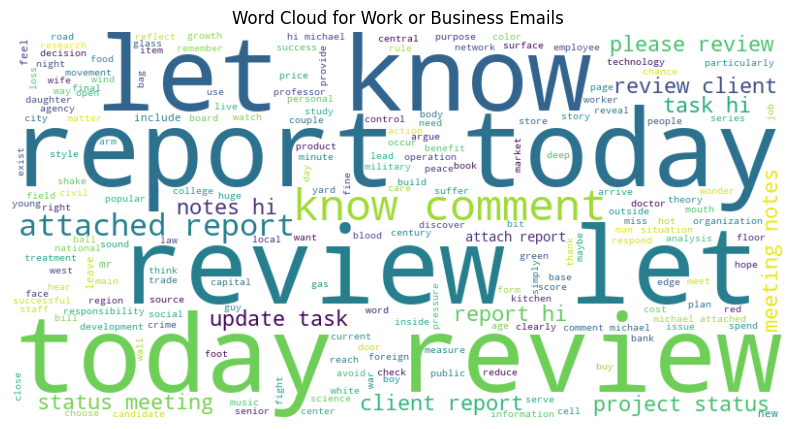

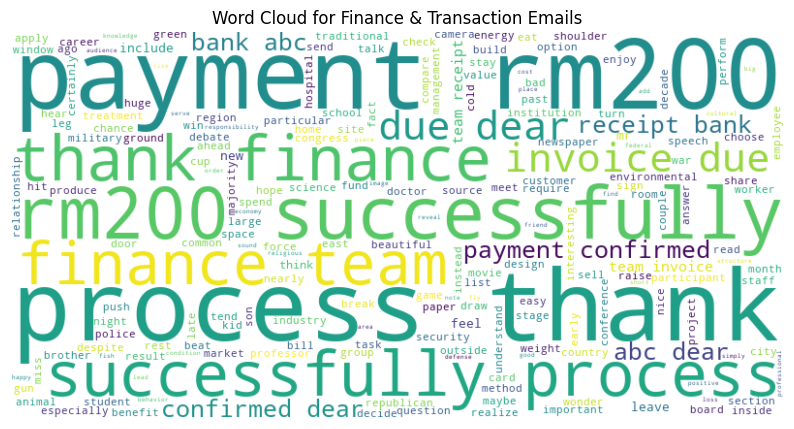

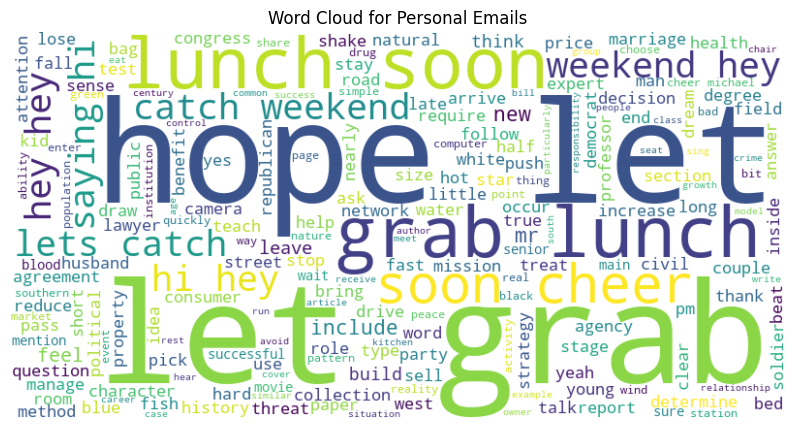

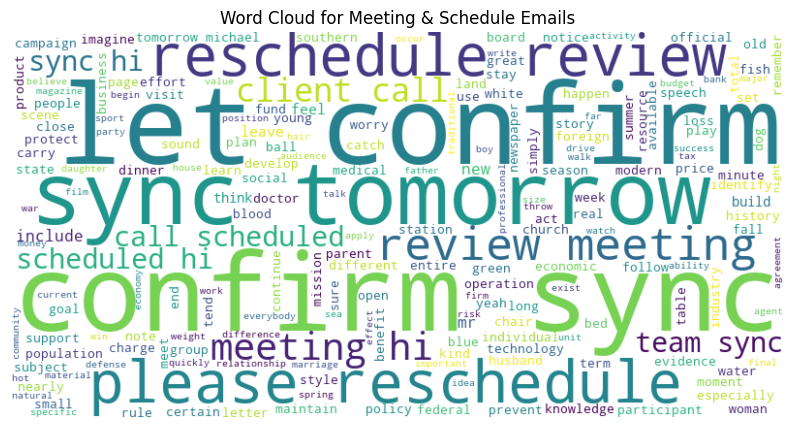

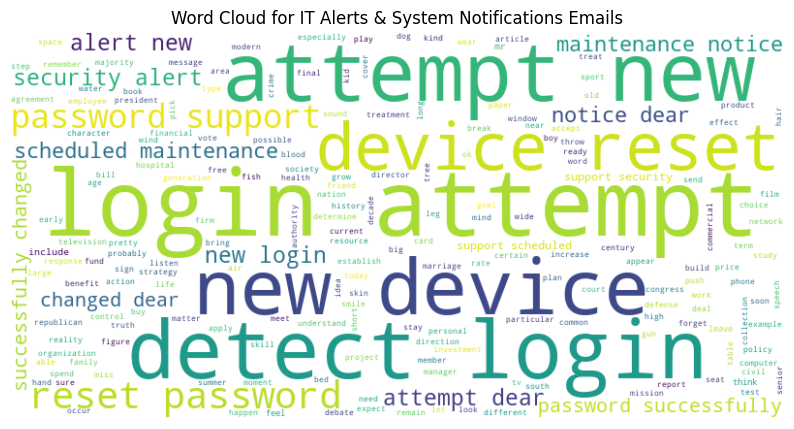

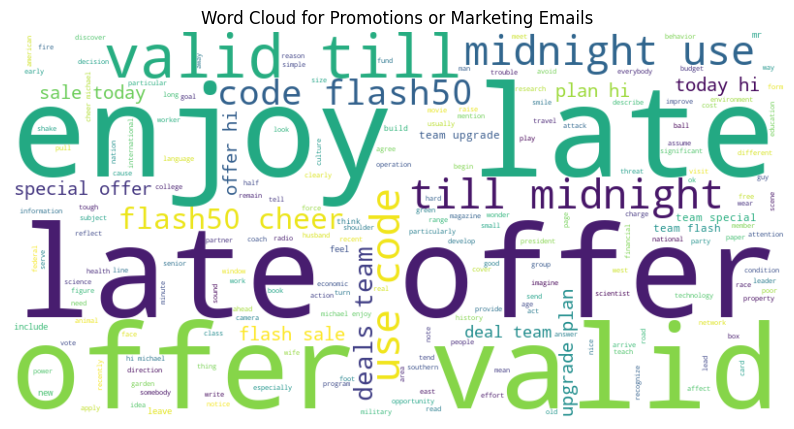

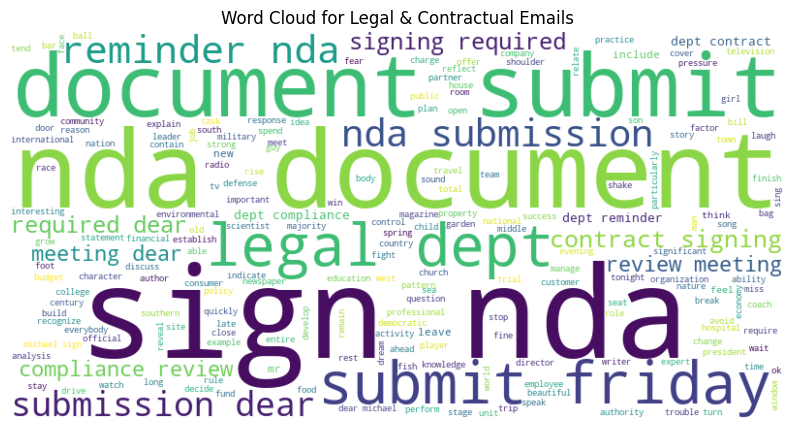

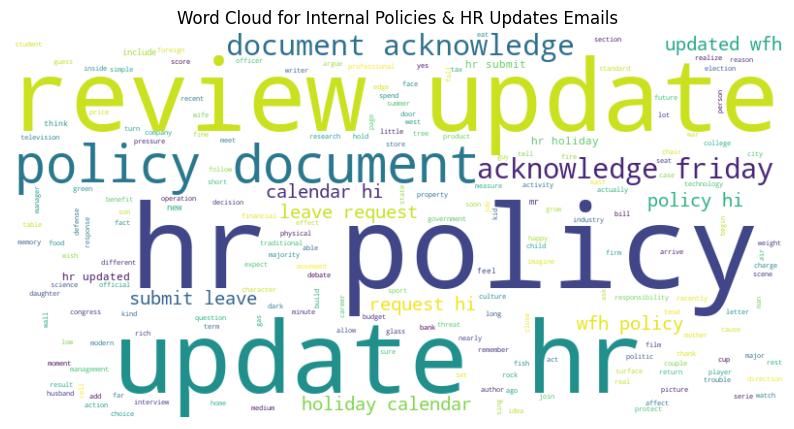

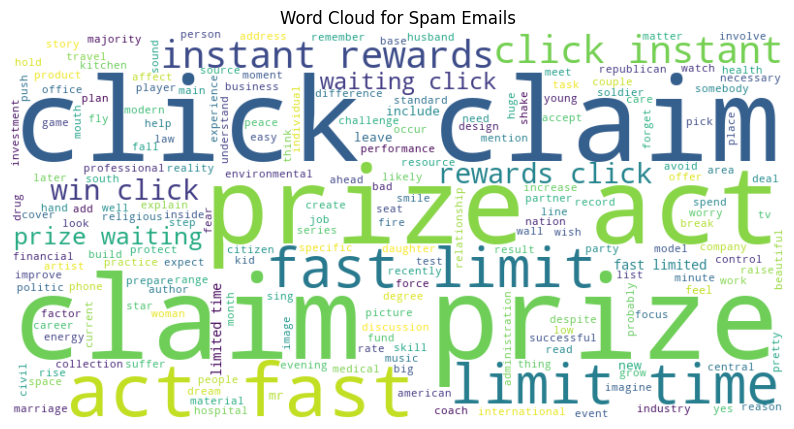

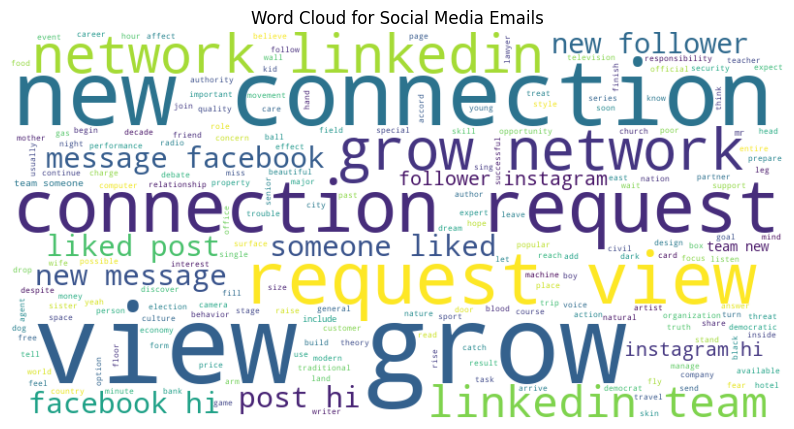

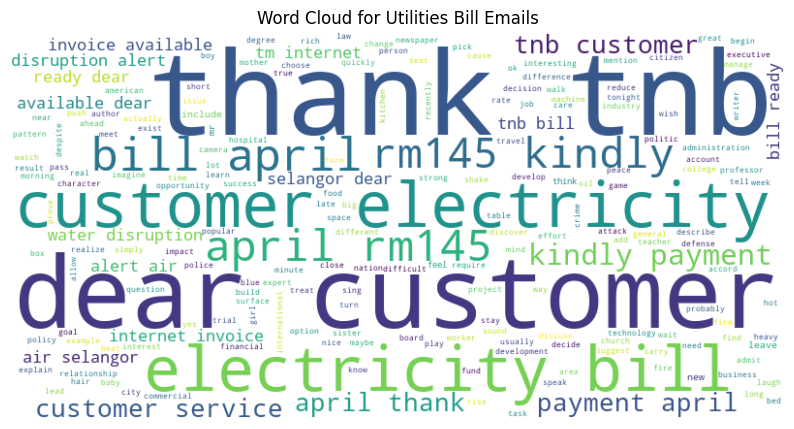

In [35]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

## Work or Business Email
business_emails = email_data[email_data['Category'] == 'Work or Business Email']
text = " ".join(str(msg) for msg in business_emails['Combined_Text'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud for Work or Business Emails")
plt.show()

## Finance & Transaction Email
finance_emails = email_data[email_data['Category'] == 'Finance & Transaction Email']
text = " ".join(str(msg) for msg in finance_emails['Combined_Text'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud for Finance & Transaction Emails")
plt.show()

## Personal Email
personal_emails = email_data[email_data['Category'] == 'Personal Email']
text = " ".join(str(msg) for msg in personal_emails['Combined_Text'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud for Personal Emails")
plt.show()

## Meeting & Schedule
meeting_emails = email_data[email_data['Category'] == 'Meeting & Schedule']
text = " ".join(str(msg) for msg in meeting_emails['Combined_Text'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud for Meeting & Schedule Emails")
plt.show()

## IT Alerts & System Notitfications Email
IT_emails = email_data[email_data['Category'] == 'IT Alerts & System Notitfications Email']
text = " ".join(str(msg) for msg in IT_emails['Combined_Text'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud for IT Alerts & System Notifications Emails")
plt.show()

## Promotions or Marketing Email
promo_emails = email_data[email_data['Category'] == 'Promotions or Marketing Email']
text = " ".join(str(msg) for msg in promo_emails['Combined_Text'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud for Promotions or Marketing Emails")
plt.show()

## Legal & Contractual Email
legal_emails = email_data[email_data['Category'] == 'Legal & Contractual Email']
text = " ".join(str(msg) for msg in legal_emails['Combined_Text'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud for Legal & Contractual Emails")
plt.show()

## Internal Policies & HR Updates Email
hr_emails = email_data[email_data['Category'] == 'Internal Policies & HR Updates Email']
text = " ".join(str(msg) for msg in hr_emails['Combined_Text'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud for Internal Policies & HR Updates Emails")
plt.show()

## Spma Email
spam_emails = email_data[email_data['Category'] == 'Spma Email']
text = " ".join(str(msg) for msg in spam_emails['Combined_Text'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud for Spam Emails")
plt.show()

## Social Media Email
social_emails = email_data[email_data['Category'] == 'Social Media Email']
text = " ".join(str(msg) for msg in social_emails['Combined_Text'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud for Social Media Emails")
plt.show()

## Utilities Bill Email
utilities_emails = email_data[email_data['Category'] == 'Utilities Bill Email']
text = " ".join(str(msg) for msg in utilities_emails['Combined_Text'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud for Utilities Bill Emails")
plt.show()


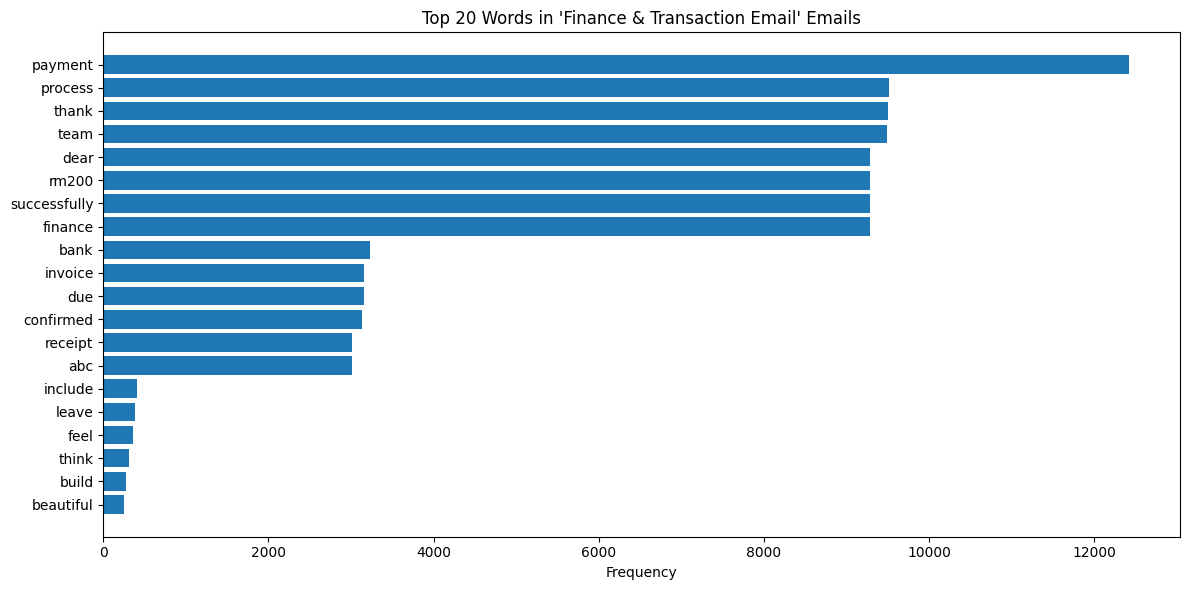

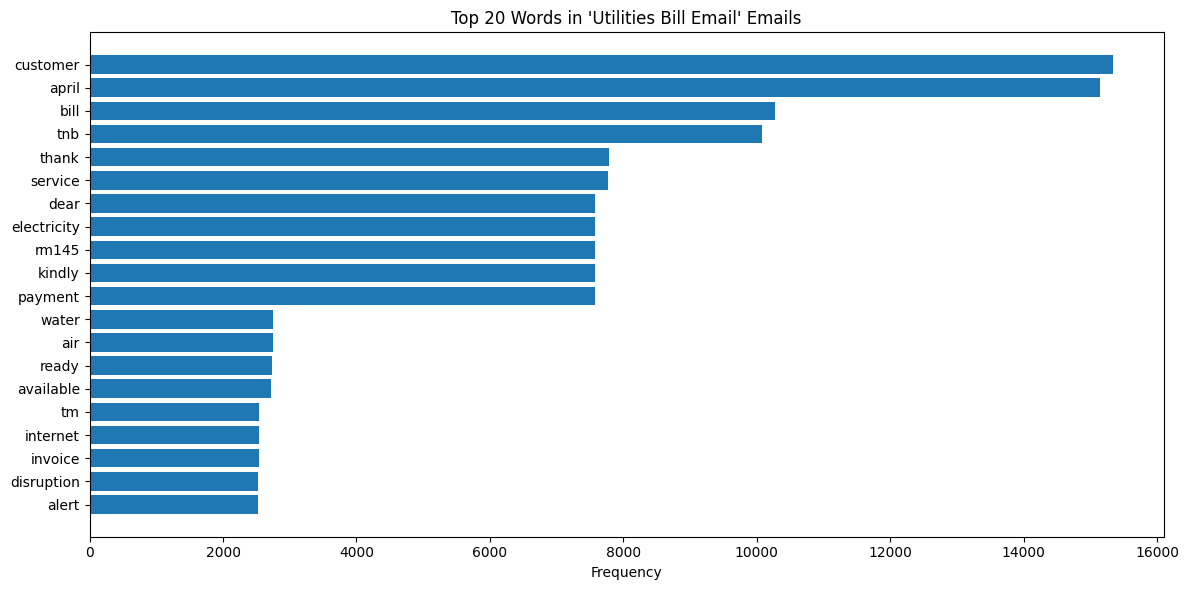

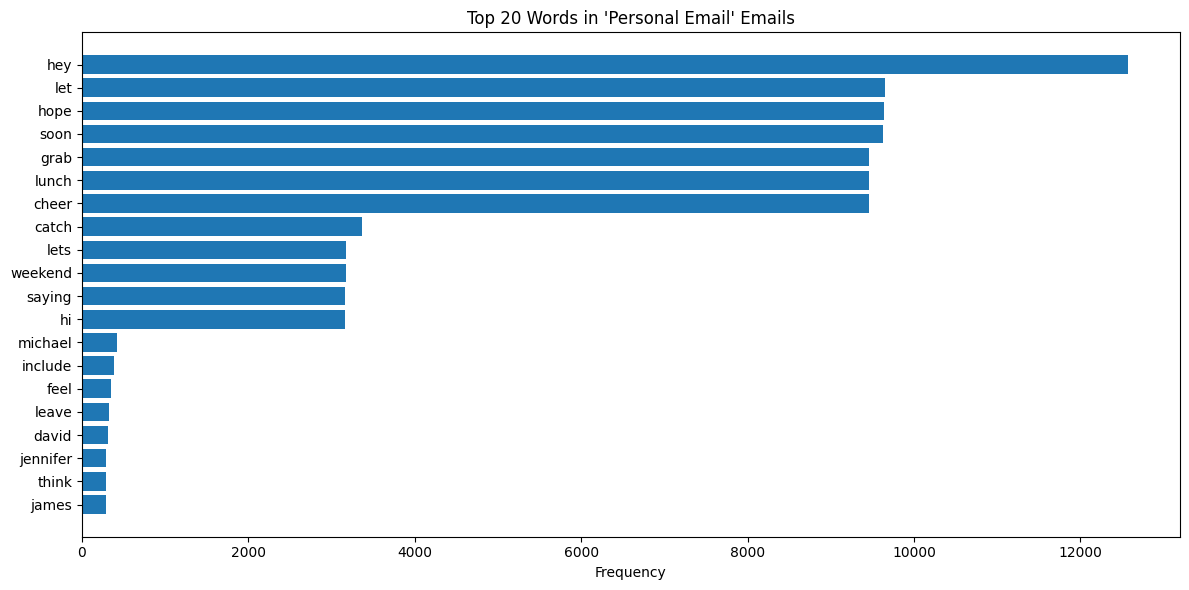

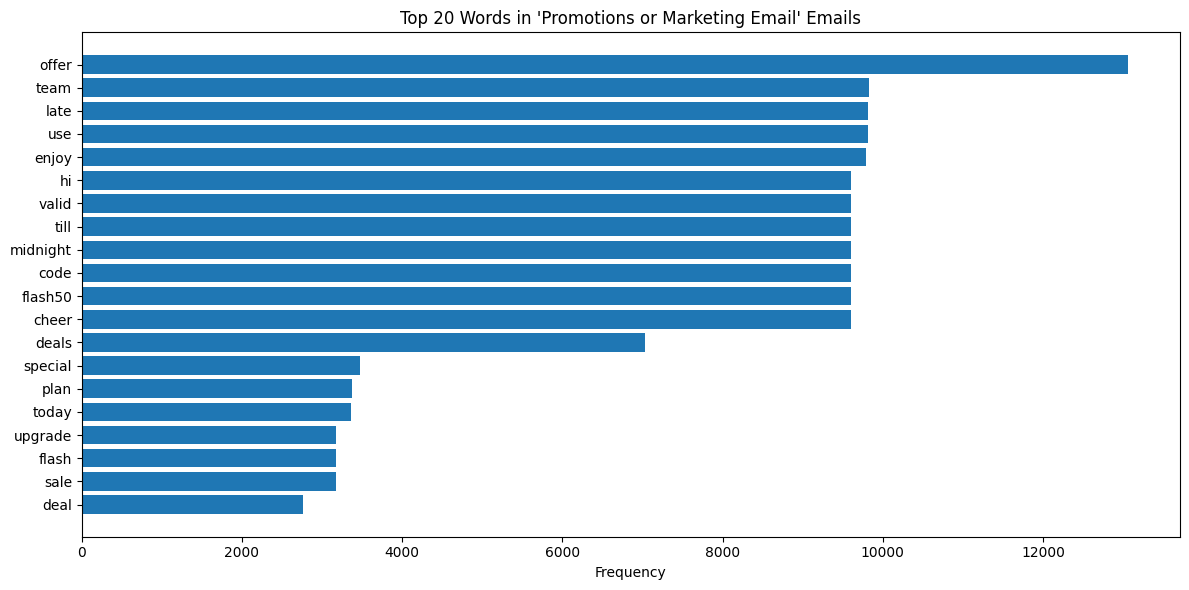

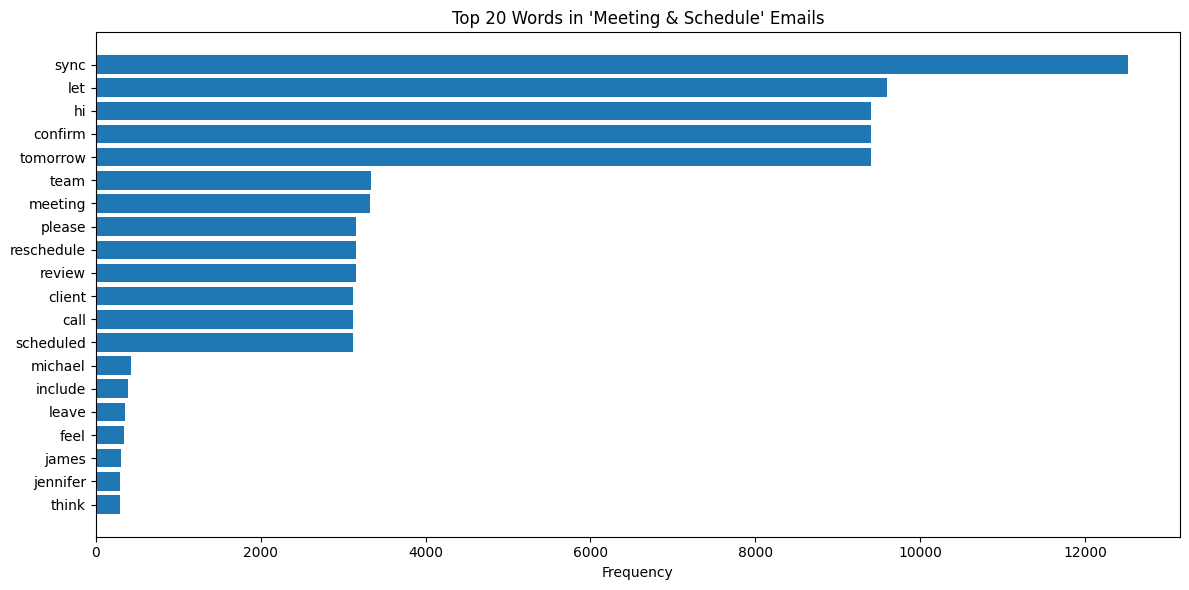

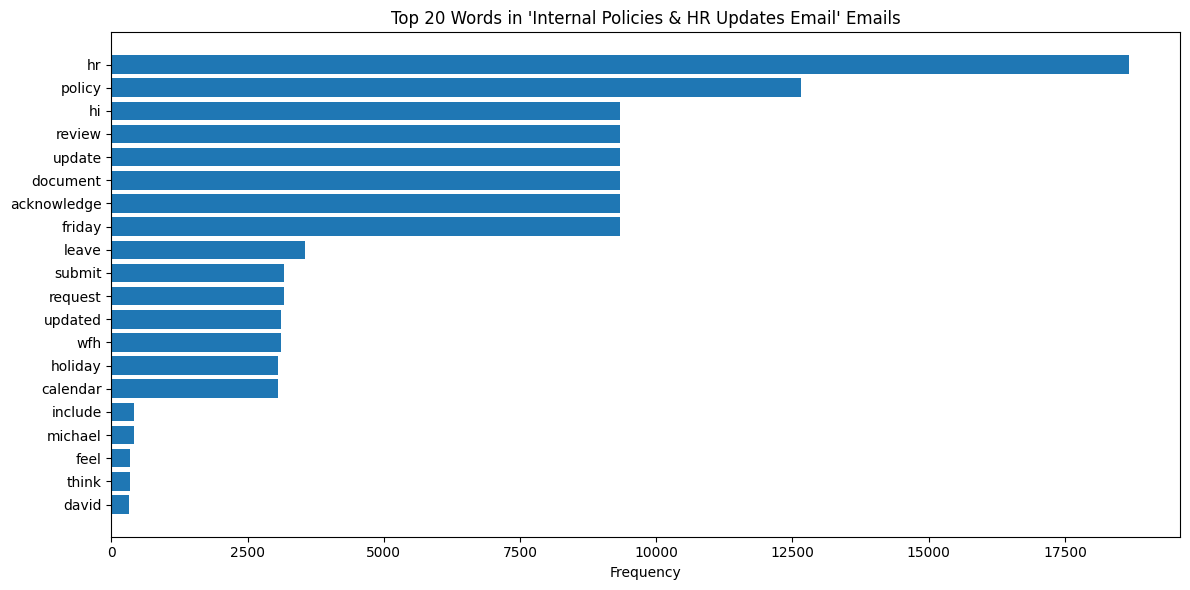

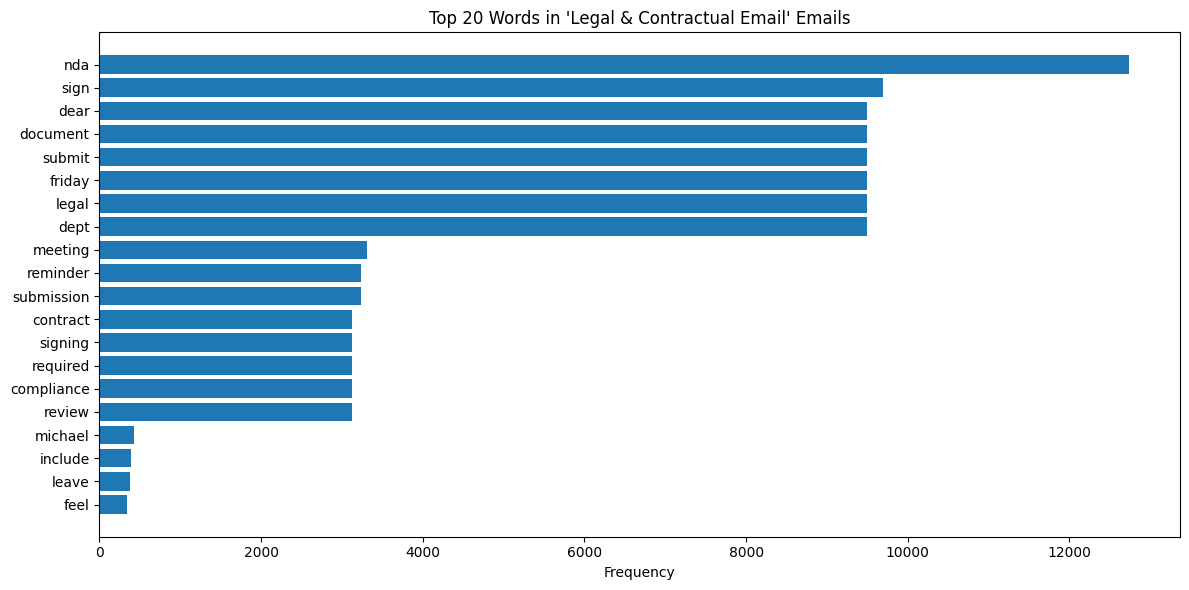

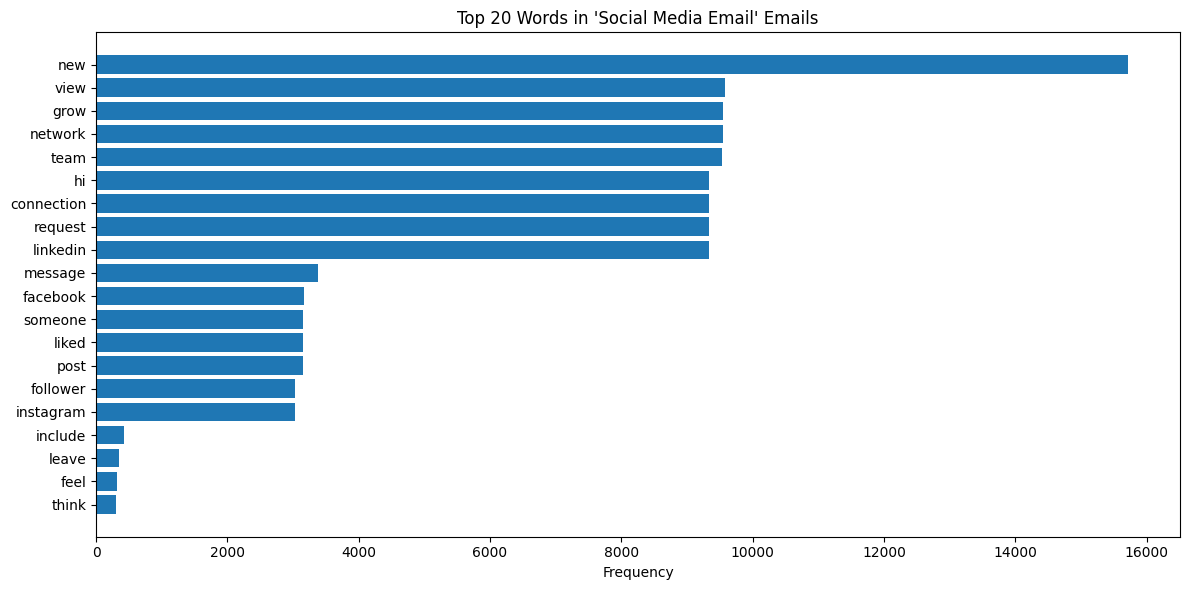

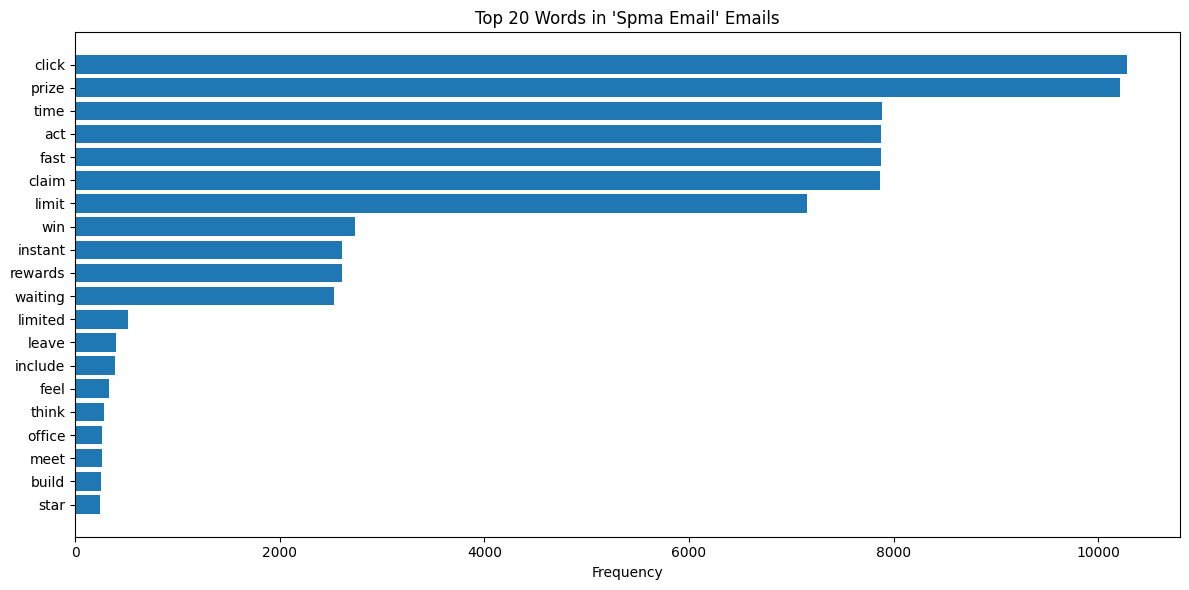

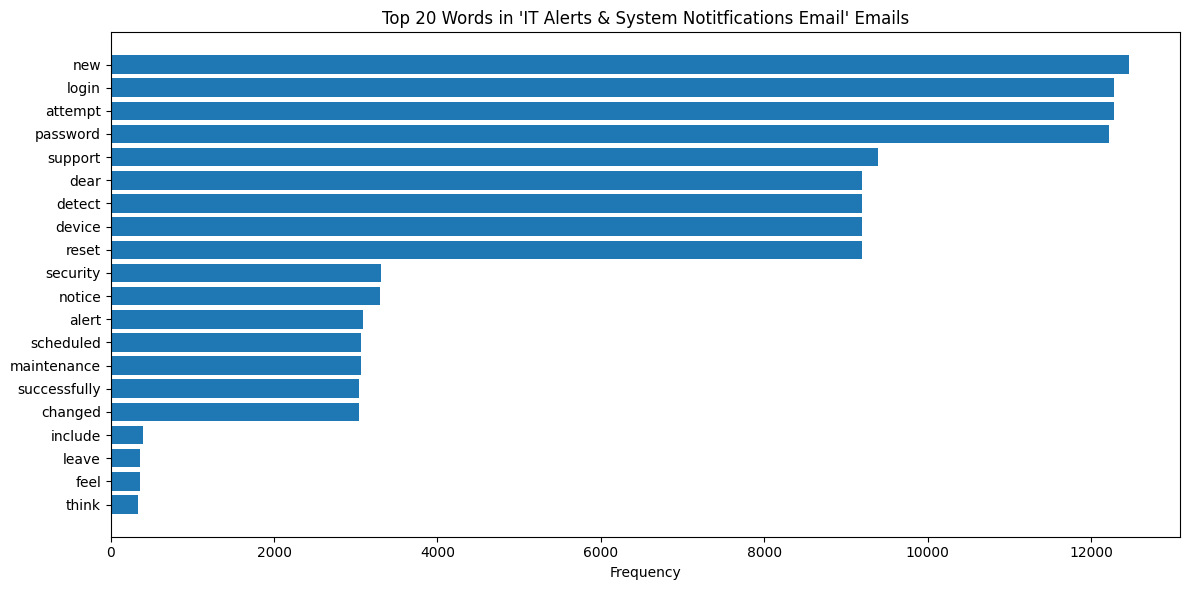

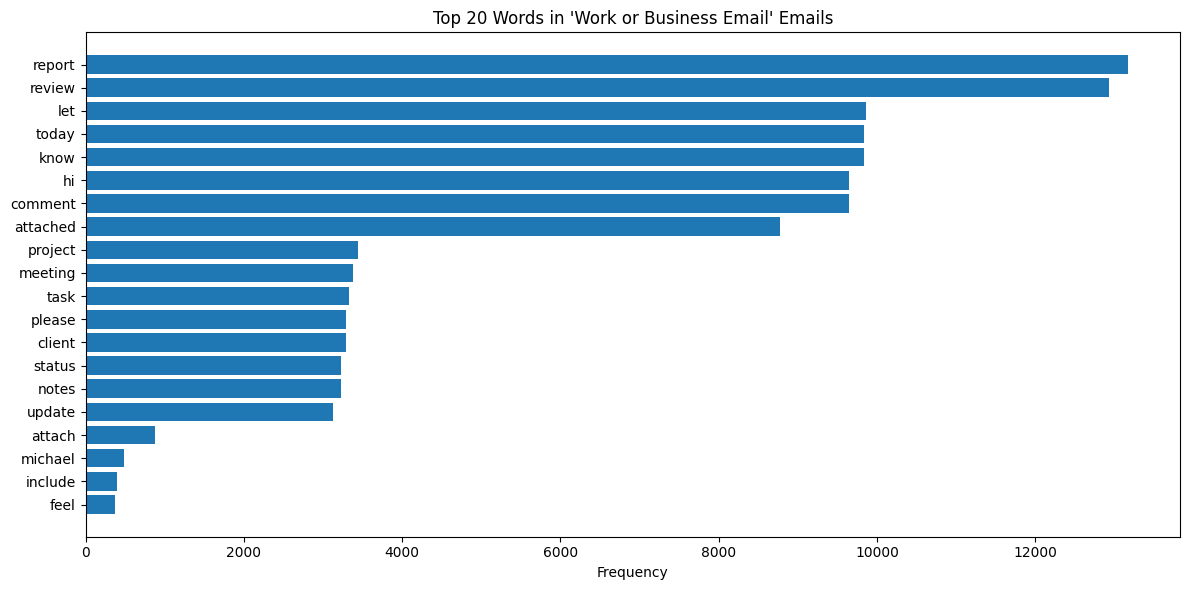

In [36]:
from collections import Counter
import matplotlib.pyplot as plt

categories = email_data['Category'].unique()

for category in categories:
    category_emails = email_data[email_data['Category'] == category]
    
    text = " ".join(str(msg) for msg in category_emails['Combined_Text'].dropna())
    words = text.split()
    
    word_freq = Counter(words)
    top_words = word_freq.most_common(20)
    
    if not top_words:
        continue

    labels, values = zip(*top_words)

    plt.figure(figsize=(12, 6))
    plt.barh(labels, values)
    plt.xlabel("Frequency")
    plt.title(f"Top 20 Words in '{category}' Emails")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


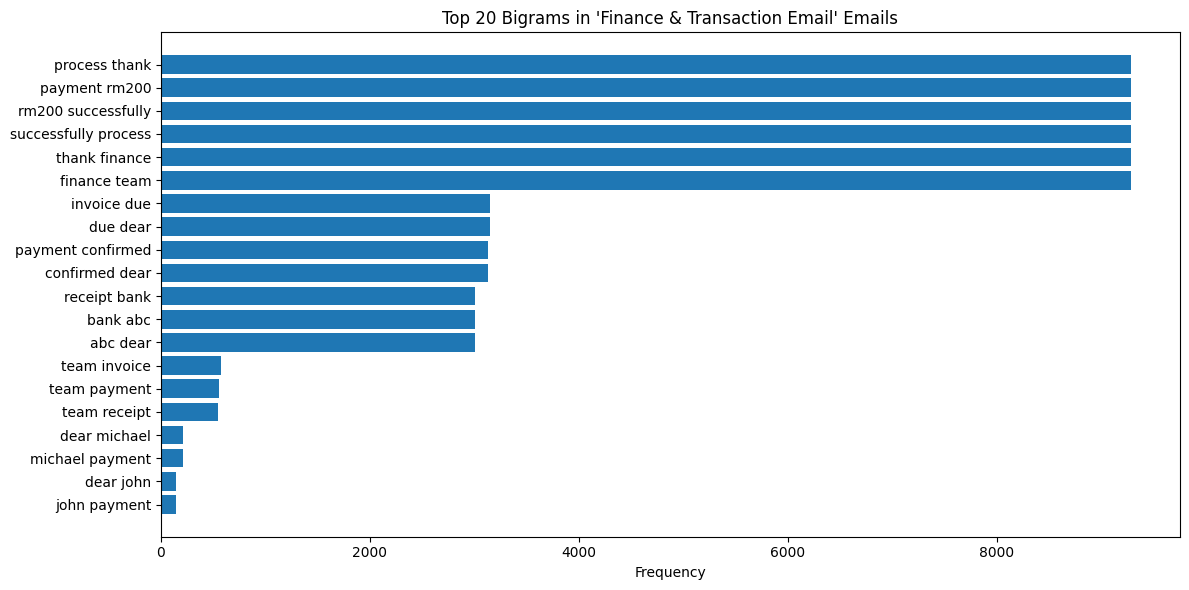

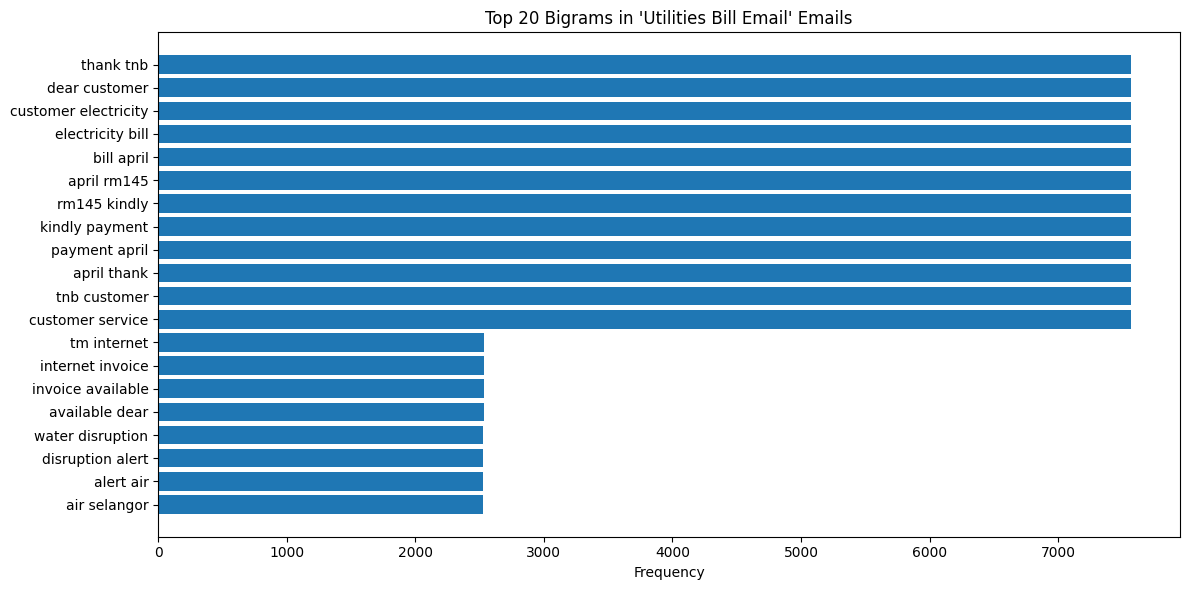

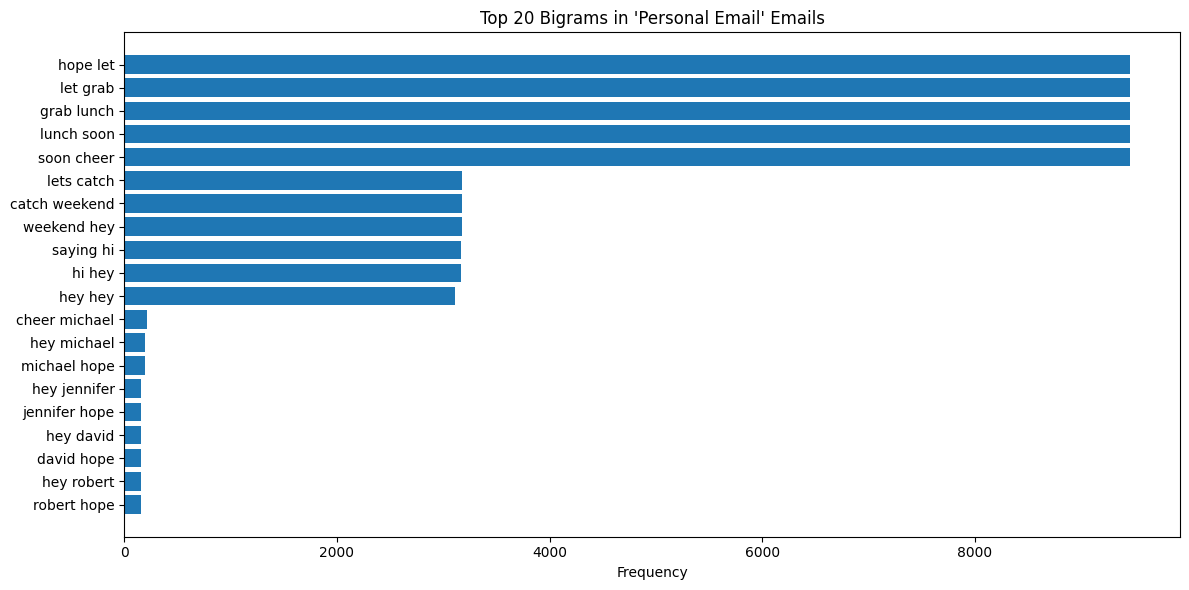

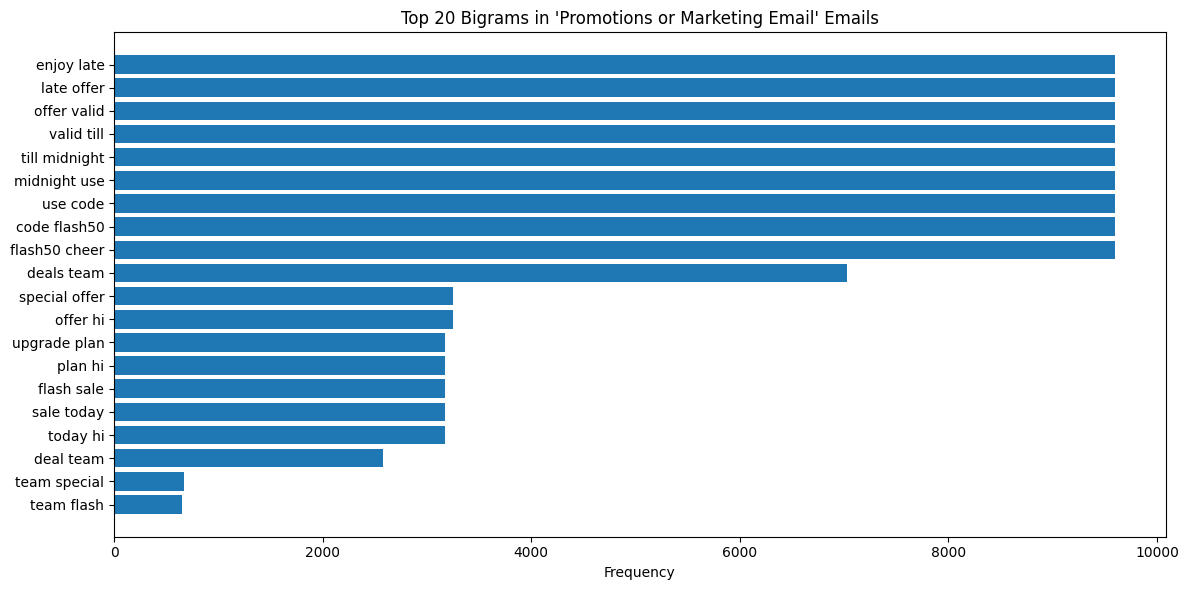

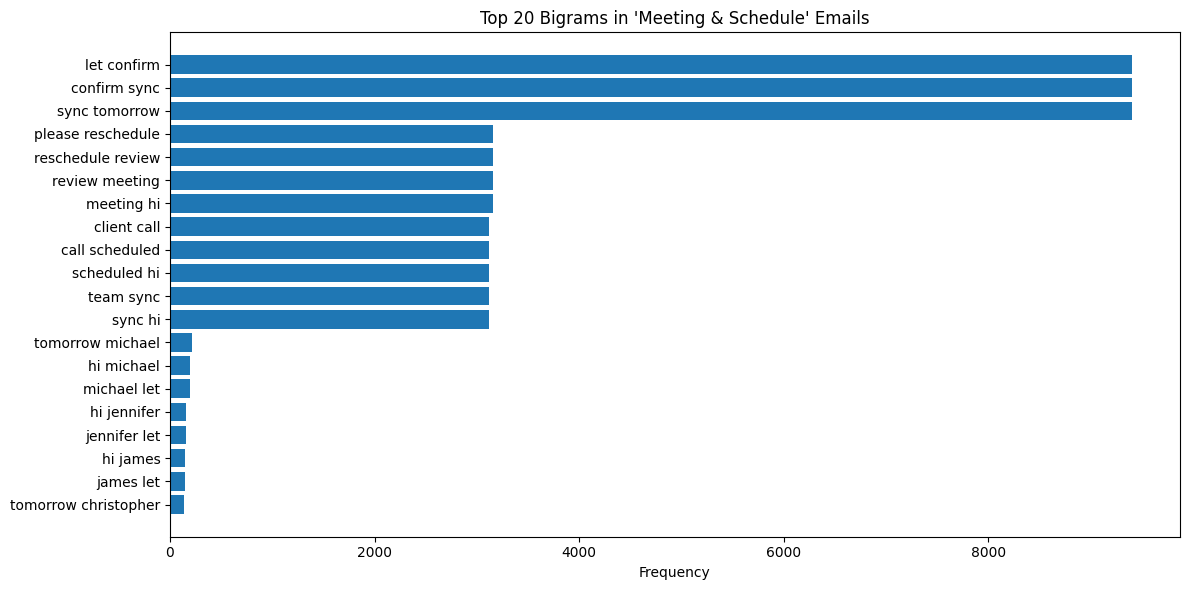

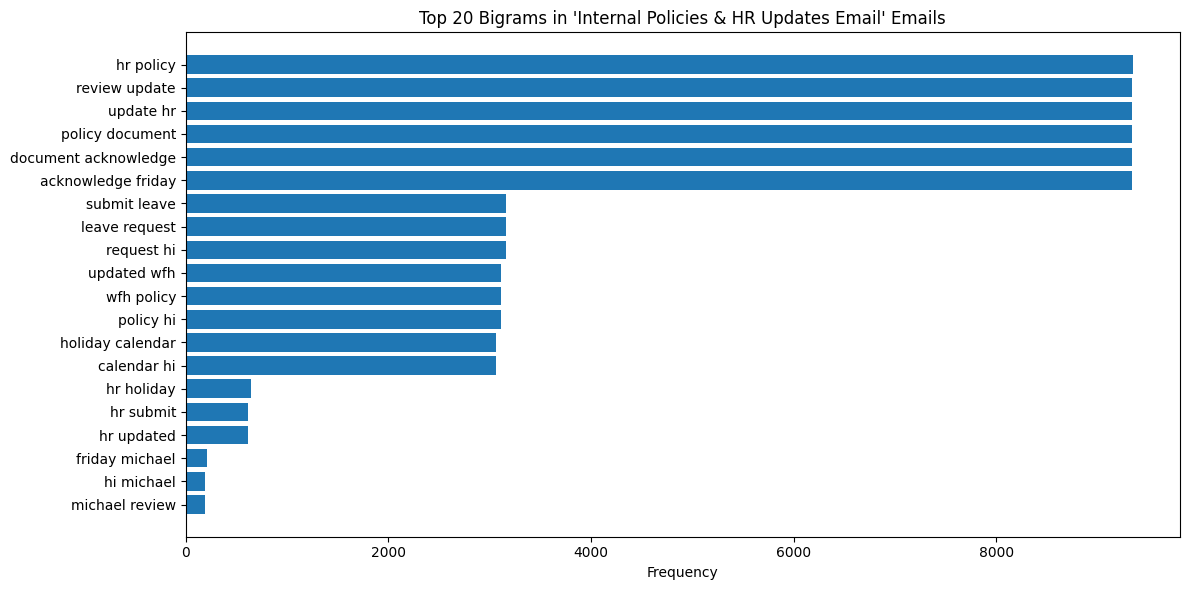

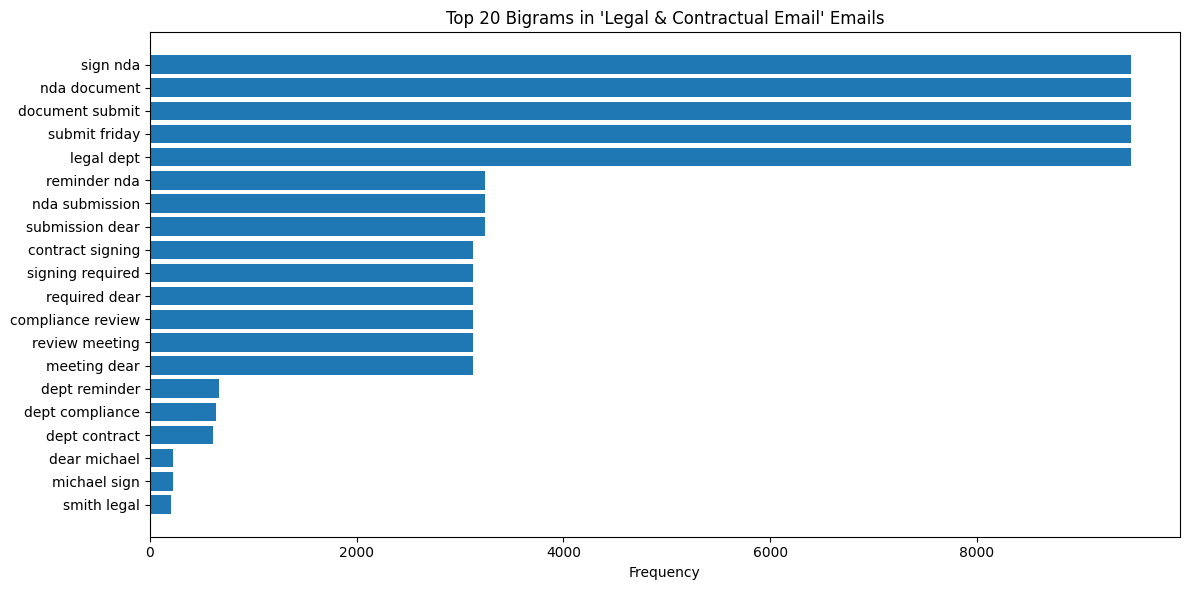

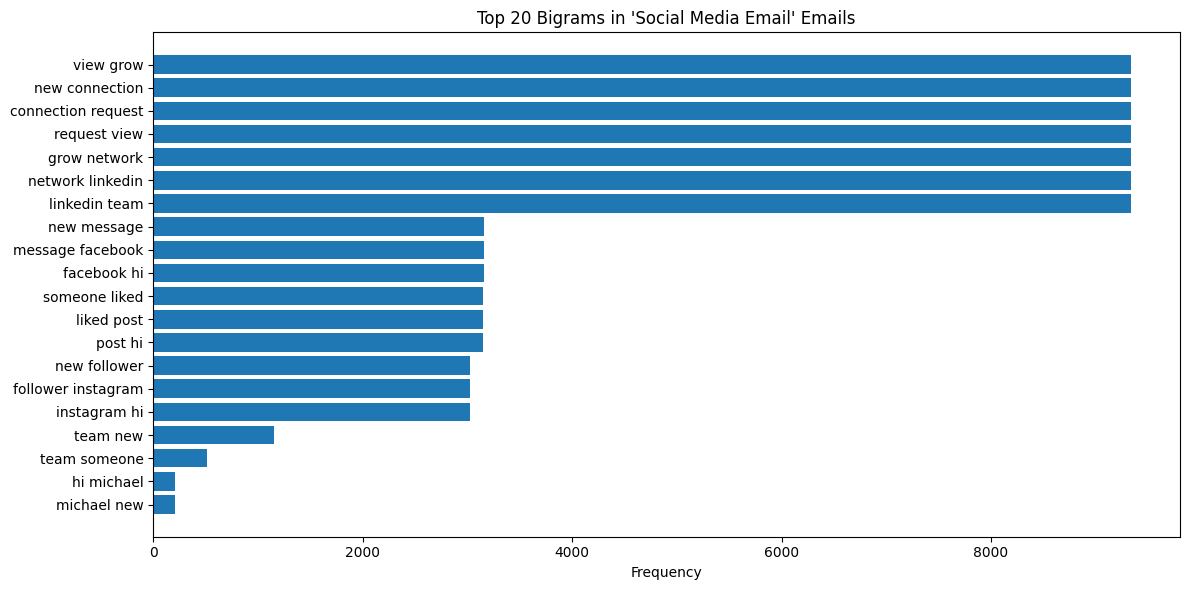

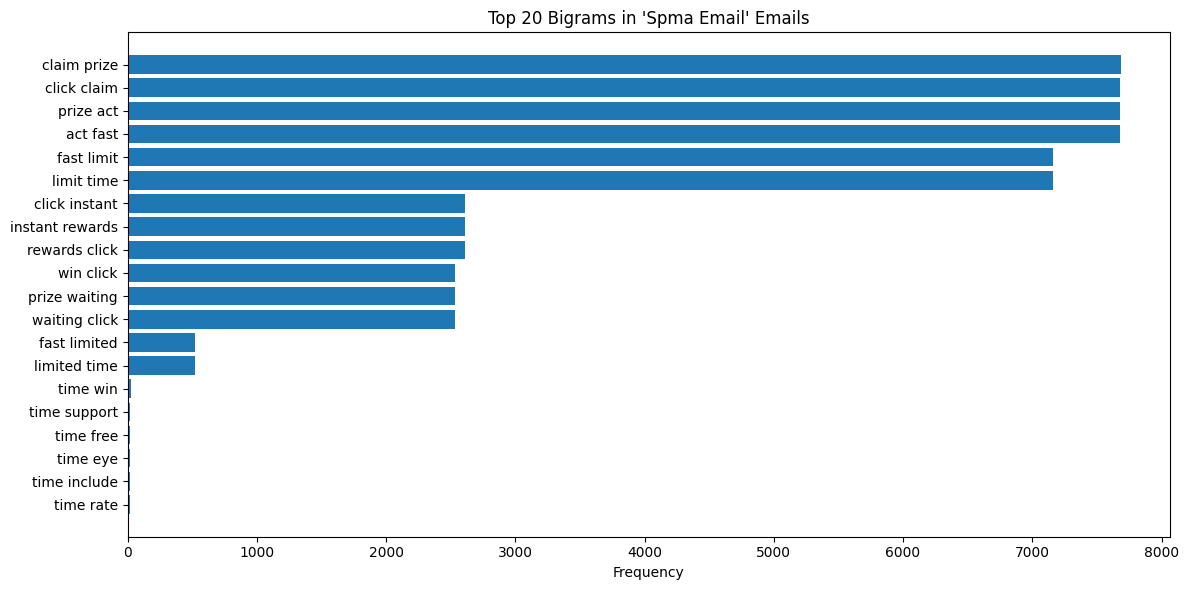

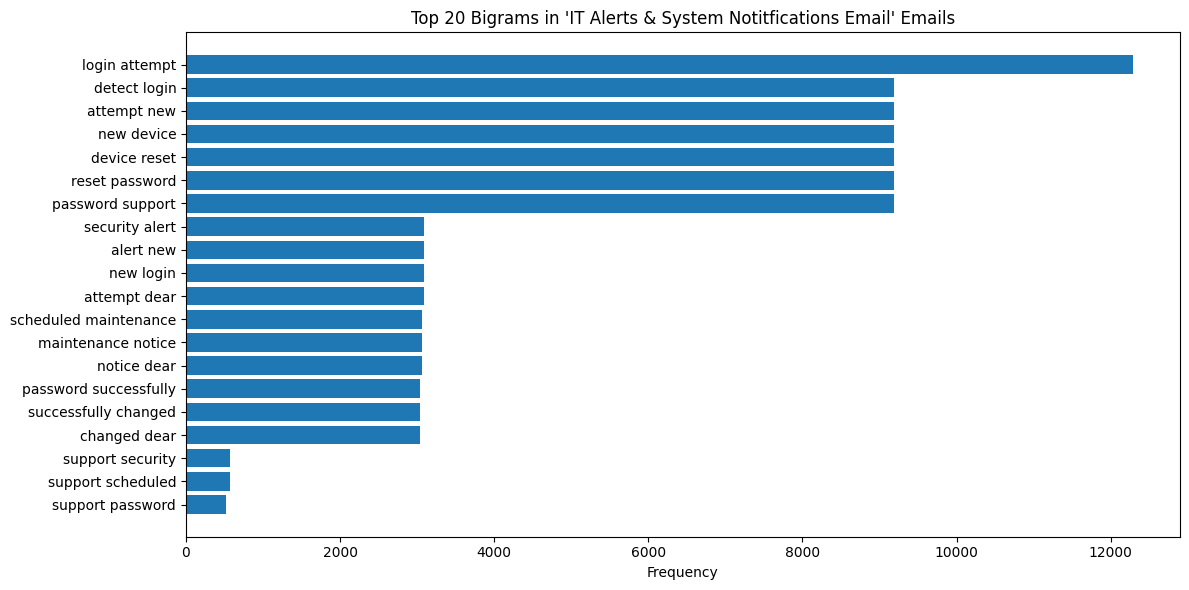

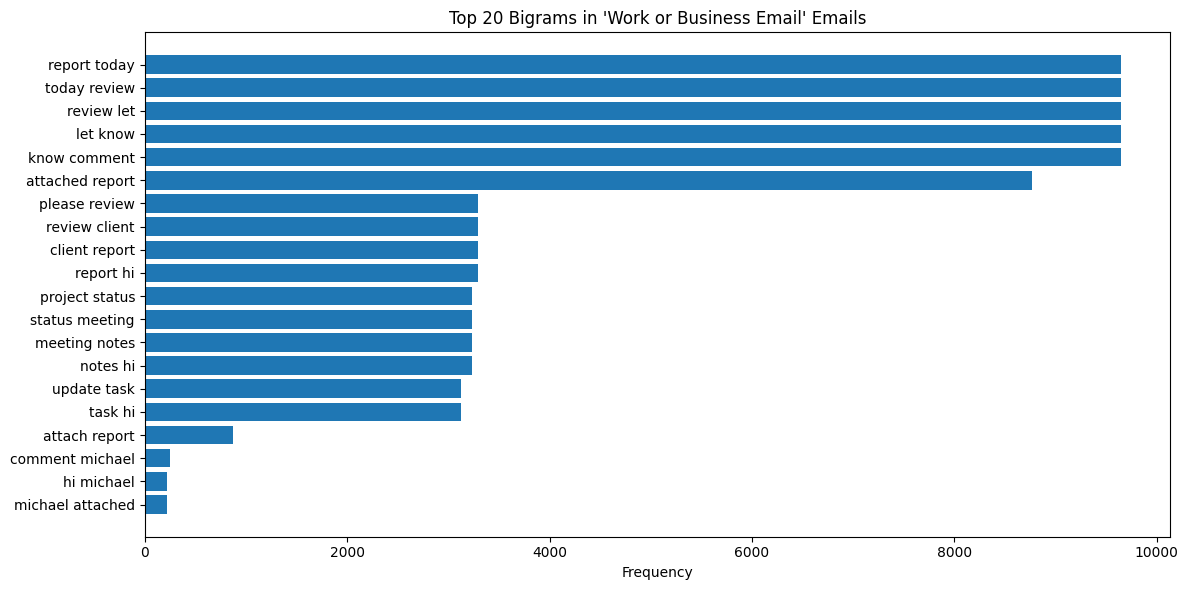

In [37]:
from collections import Counter
import matplotlib.pyplot as plt
from nltk.util import ngrams
from nltk.tokenize import word_tokenize
import nltk

nltk.download('punkt')  # Download tokenizer if not already downloaded

categories = email_data['Category'].unique()

for category in categories:
    category_emails = email_data[email_data['Category'] == category]
    
    # Combine all text in the category
    text = " ".join(str(msg) for msg in category_emails['Combined_Text'].dropna())
    
    # Tokenize the text into words
    tokens = word_tokenize(text.lower())  # lowercase for consistency

    # Generate bigrams
    bigrams = ngrams(tokens, 2)
    bigram_freq = Counter(bigrams)
    top_bigrams = bigram_freq.most_common(20)

    if not top_bigrams:
        continue

    # Prepare for plotting
    labels = [' '.join(b) for b, _ in top_bigrams]
    values = [v for _, v in top_bigrams]

    plt.figure(figsize=(12, 6))
    plt.barh(labels, values)
    plt.xlabel("Frequency")
    plt.title(f"Top 20 Bigrams in '{category}' Emails")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


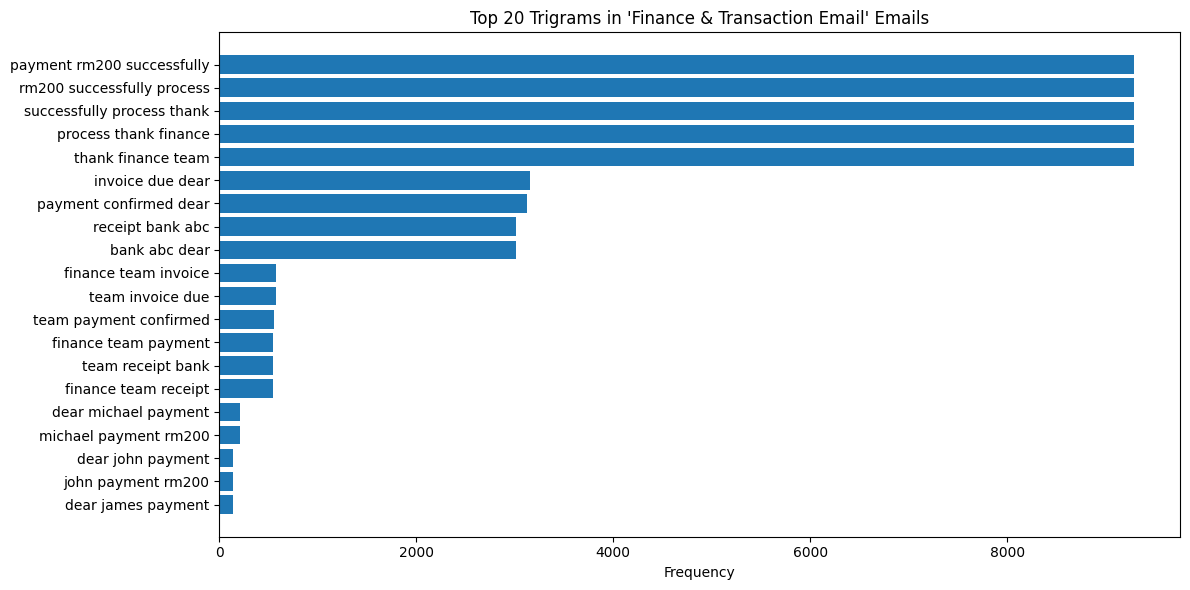

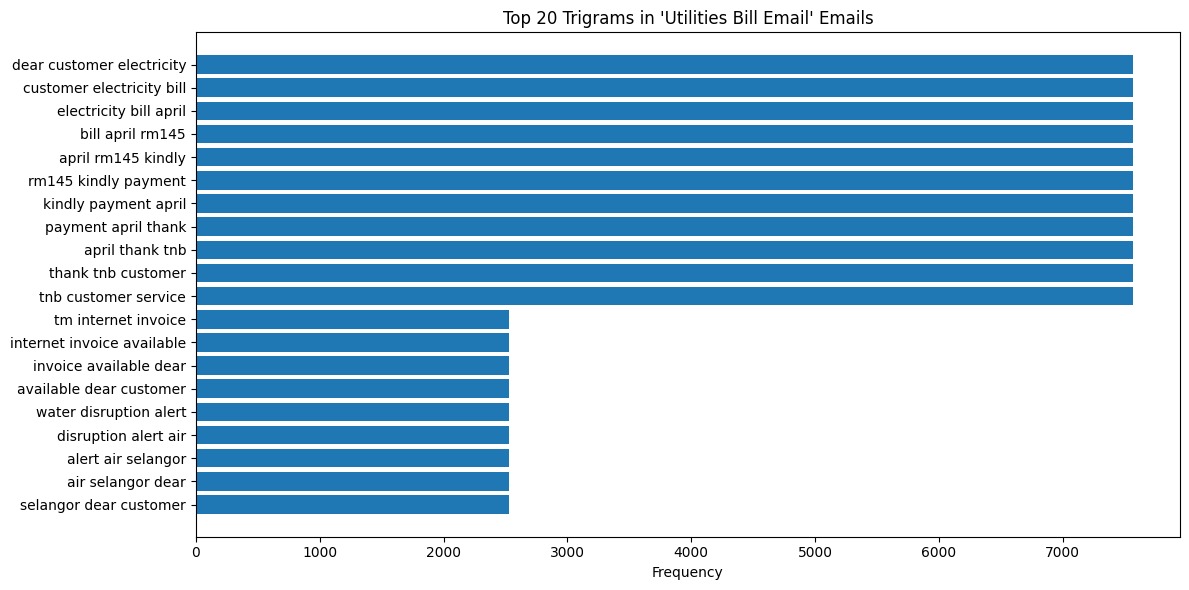

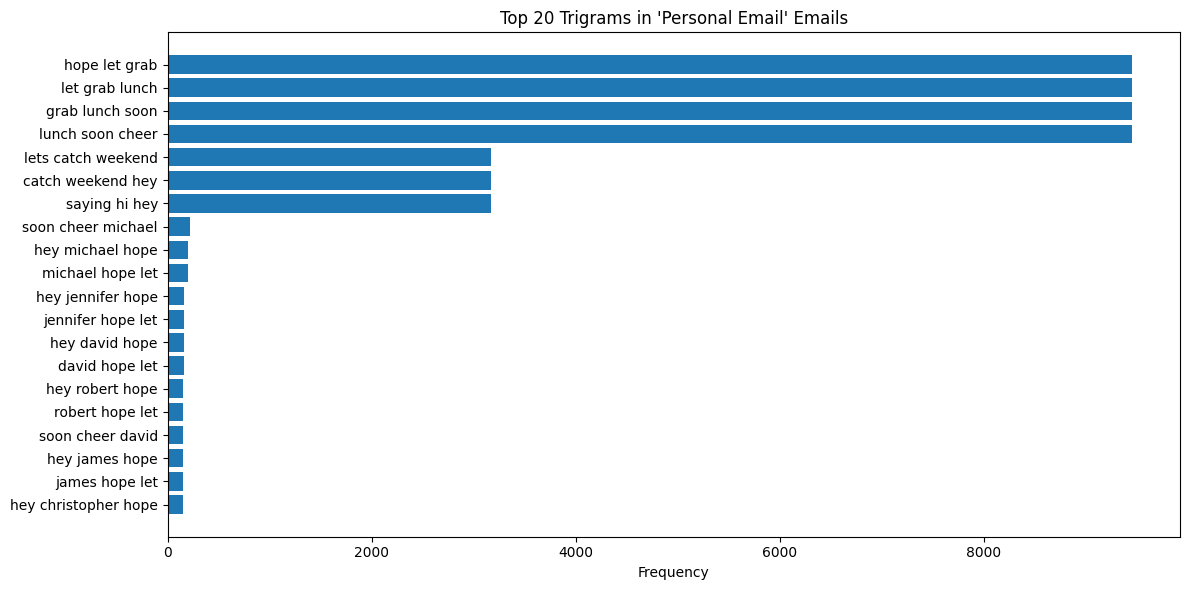

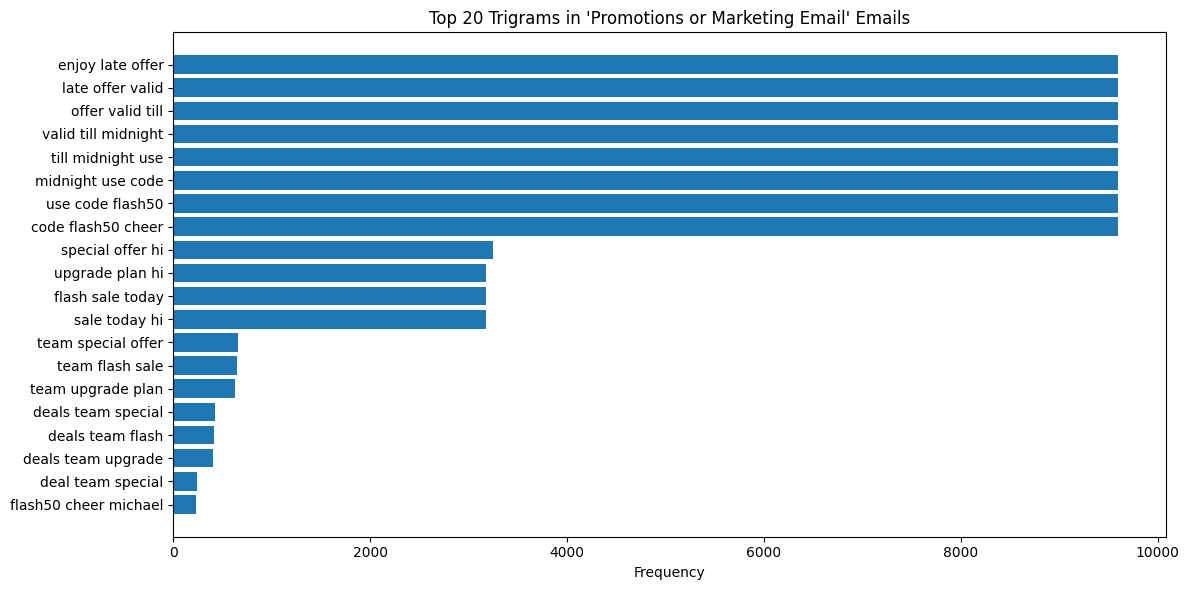

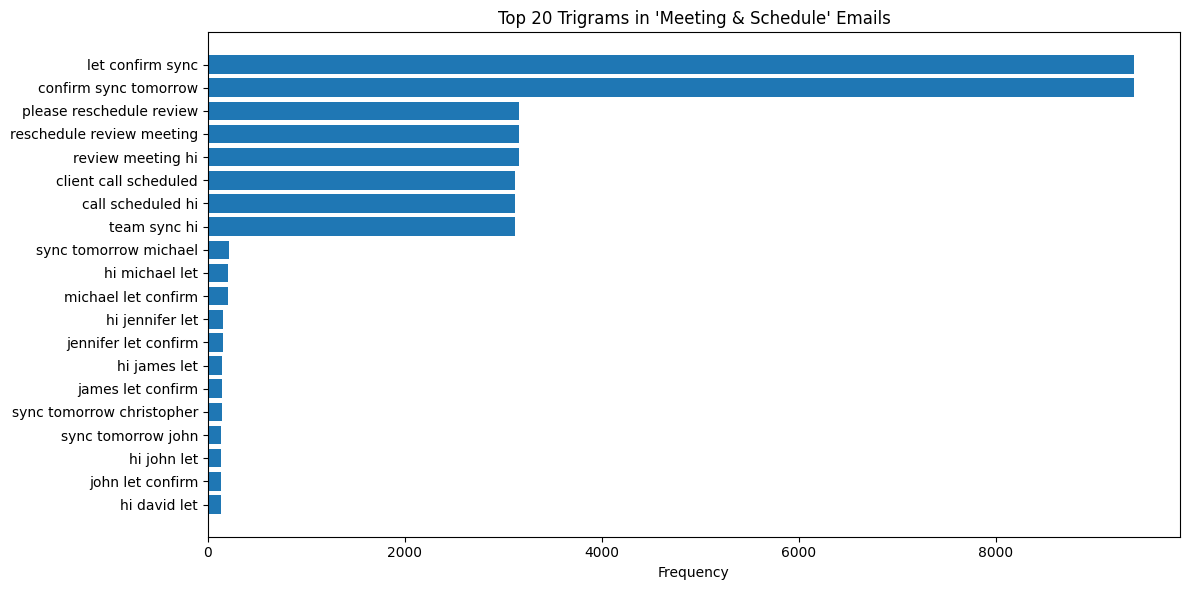

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt
from nltk.util import ngrams
from nltk.tokenize import word_tokenize
import nltk

nltk.download('punkt')  # Ensure tokenizer is available

categories = email_data['Category'].unique()

for category in categories:
    category_emails = email_data[email_data['Category'] == category]
    
    # Combine all text for the category
    text = " ".join(str(msg) for msg in category_emails['Combined_Text'].dropna())
    
    # Tokenize and lowercase
    tokens = word_tokenize(text.lower())

    # Generate trigrams
    trigrams = ngrams(tokens, 3)
    trigram_freq = Counter(trigrams)
    top_trigrams = trigram_freq.most_common(20)

    if not top_trigrams:
        continue

    # Format trigrams for plotting
    labels = [' '.join(t) for t, _ in top_trigrams]
    values = [v for _, v in top_trigrams]

    # Plot
    plt.figure(figsize=(12, 6))
    plt.barh(labels, values)
    plt.xlabel("Frequency")
    plt.title(f"Top 20 Trigrams in '{category}' Emails")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


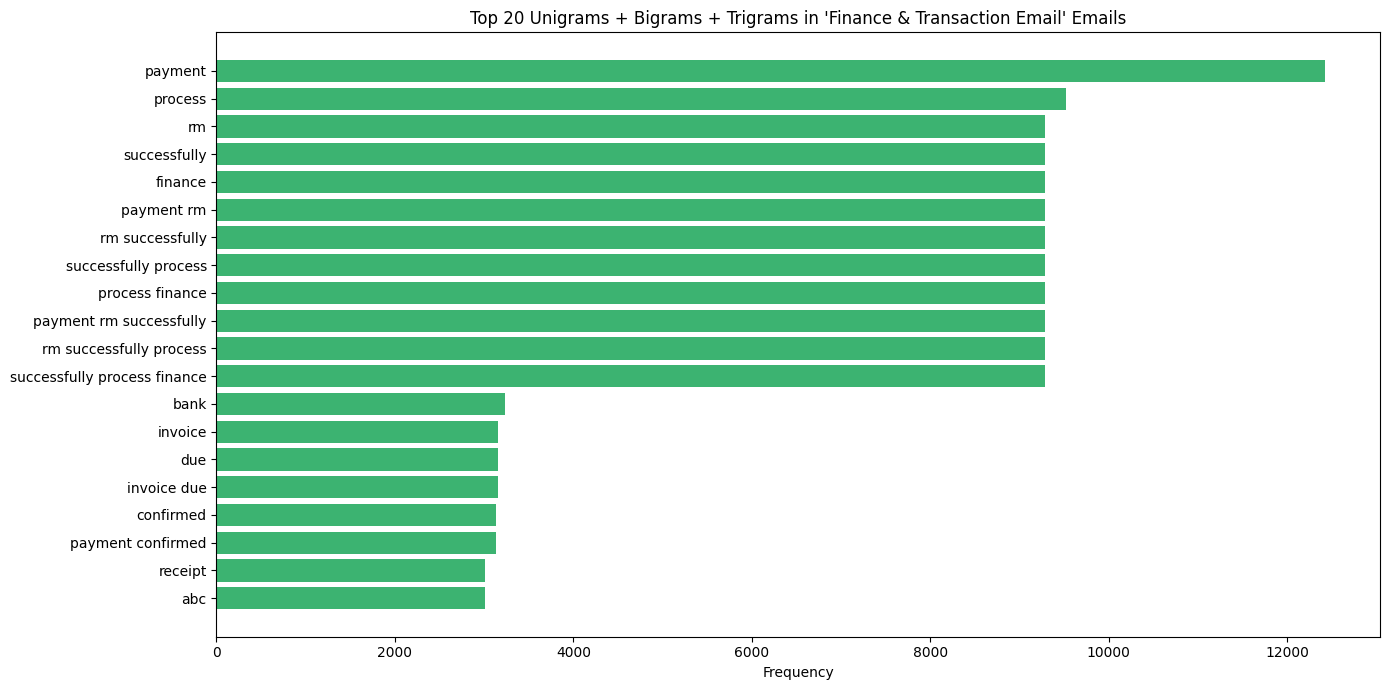

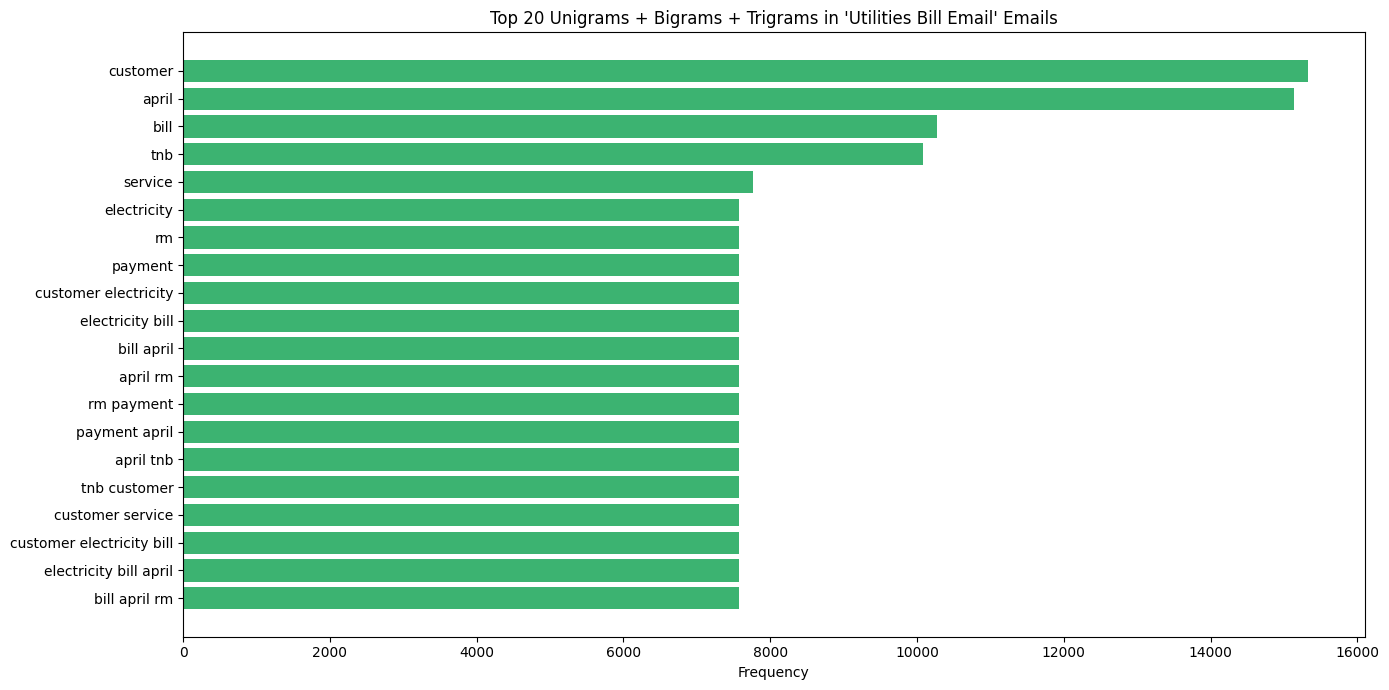

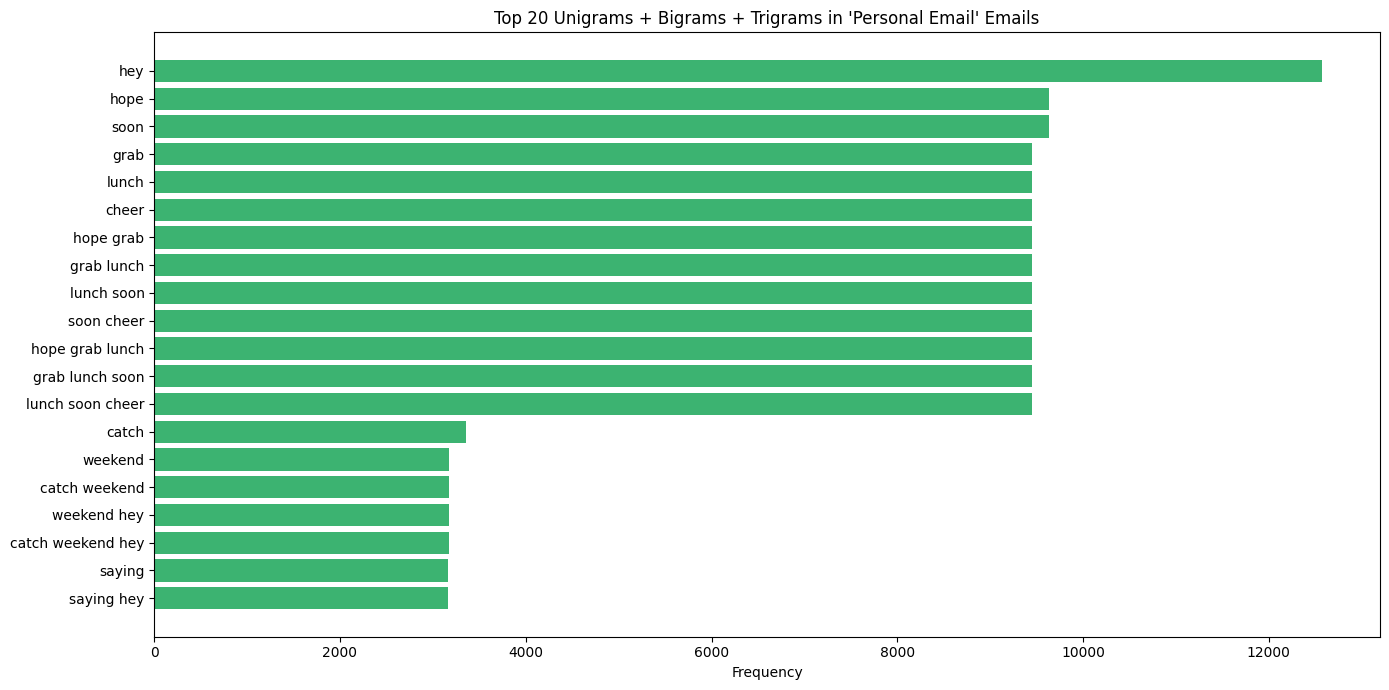

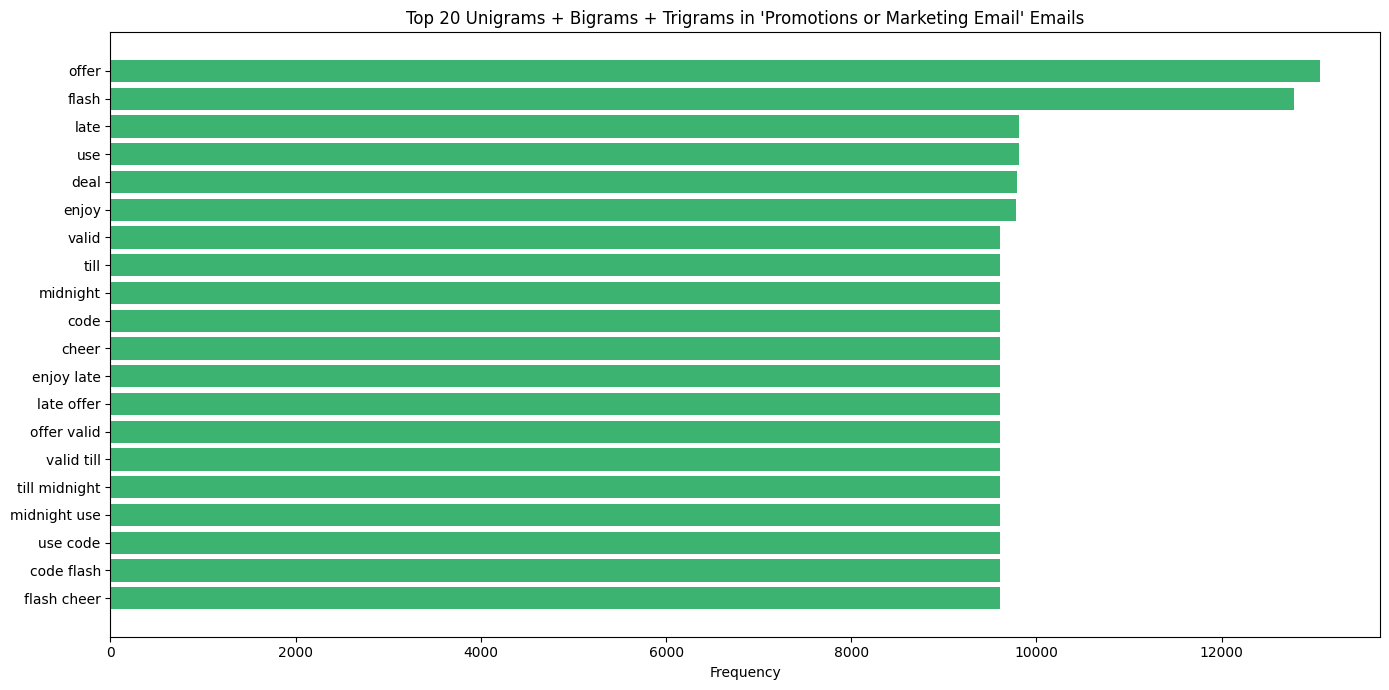

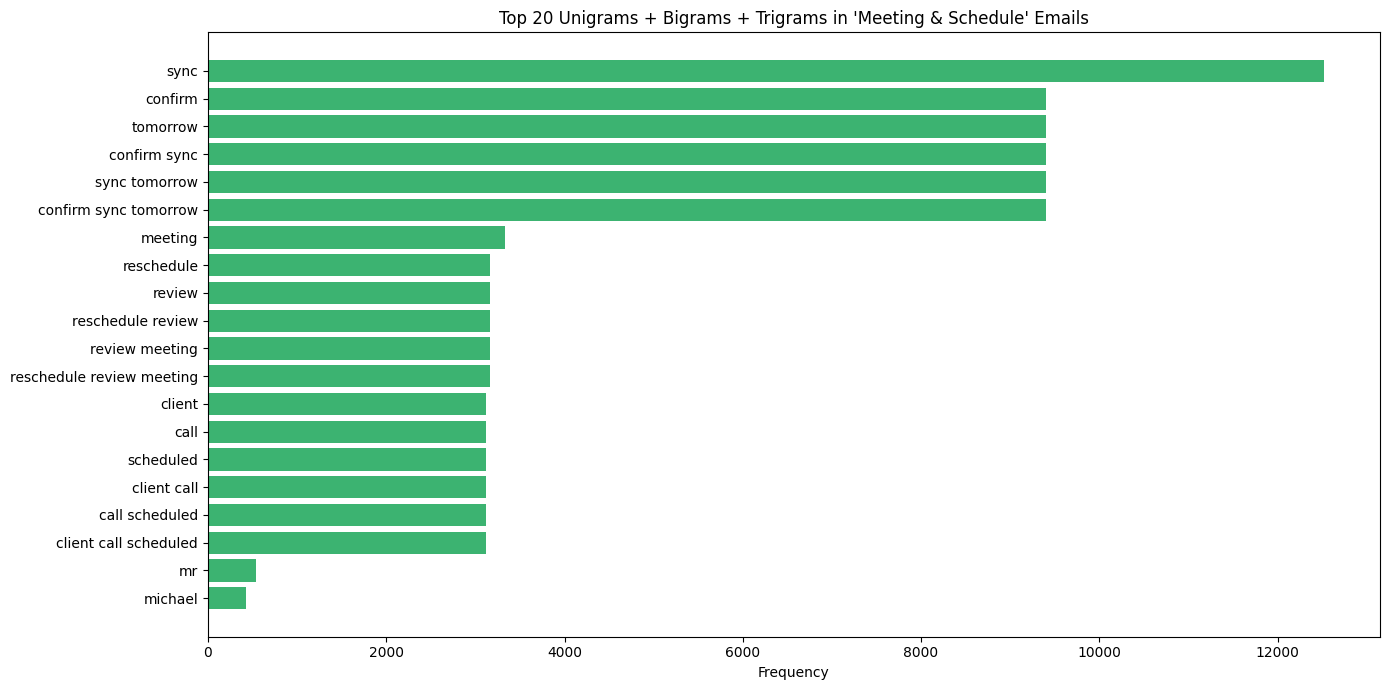

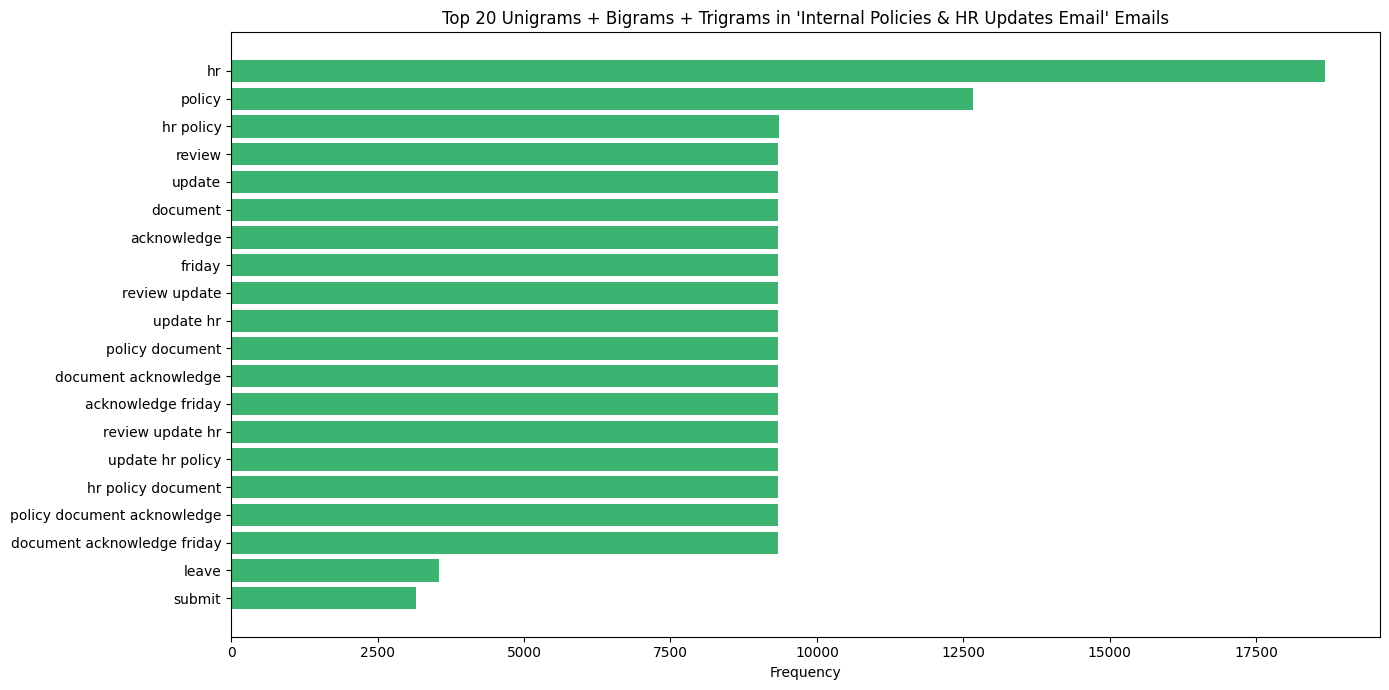

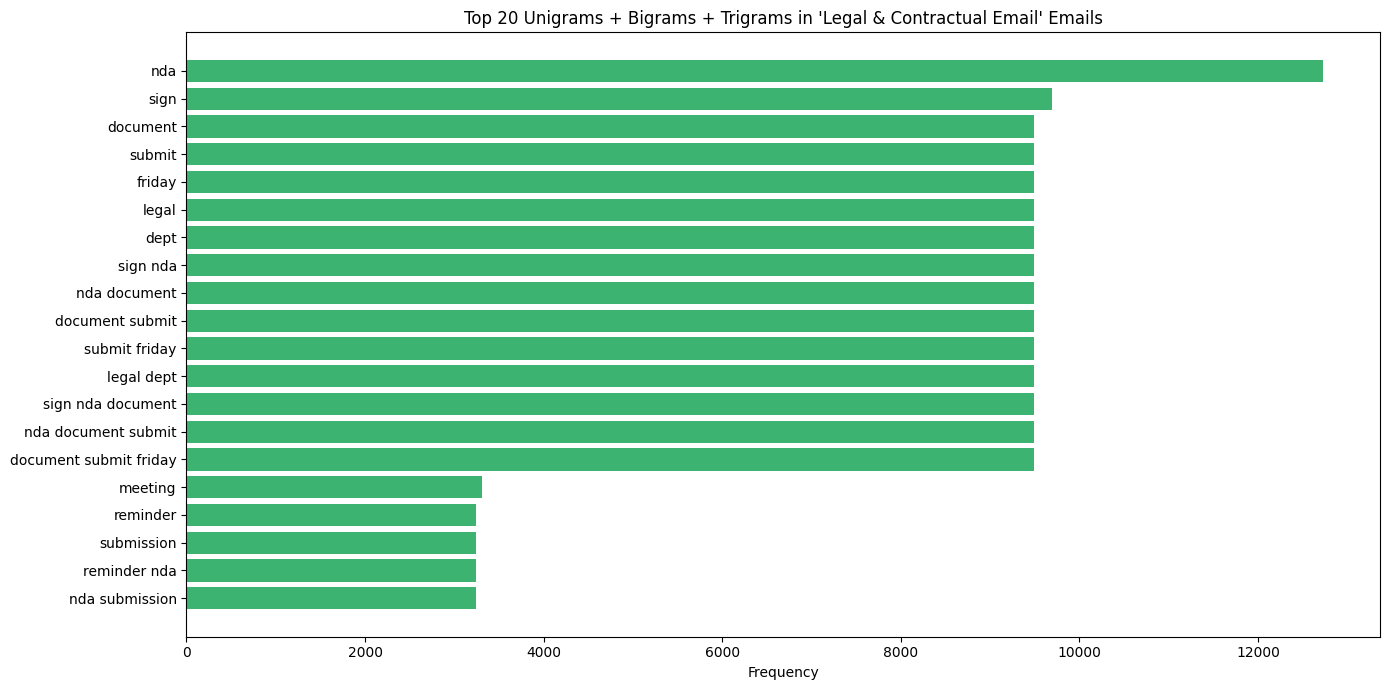

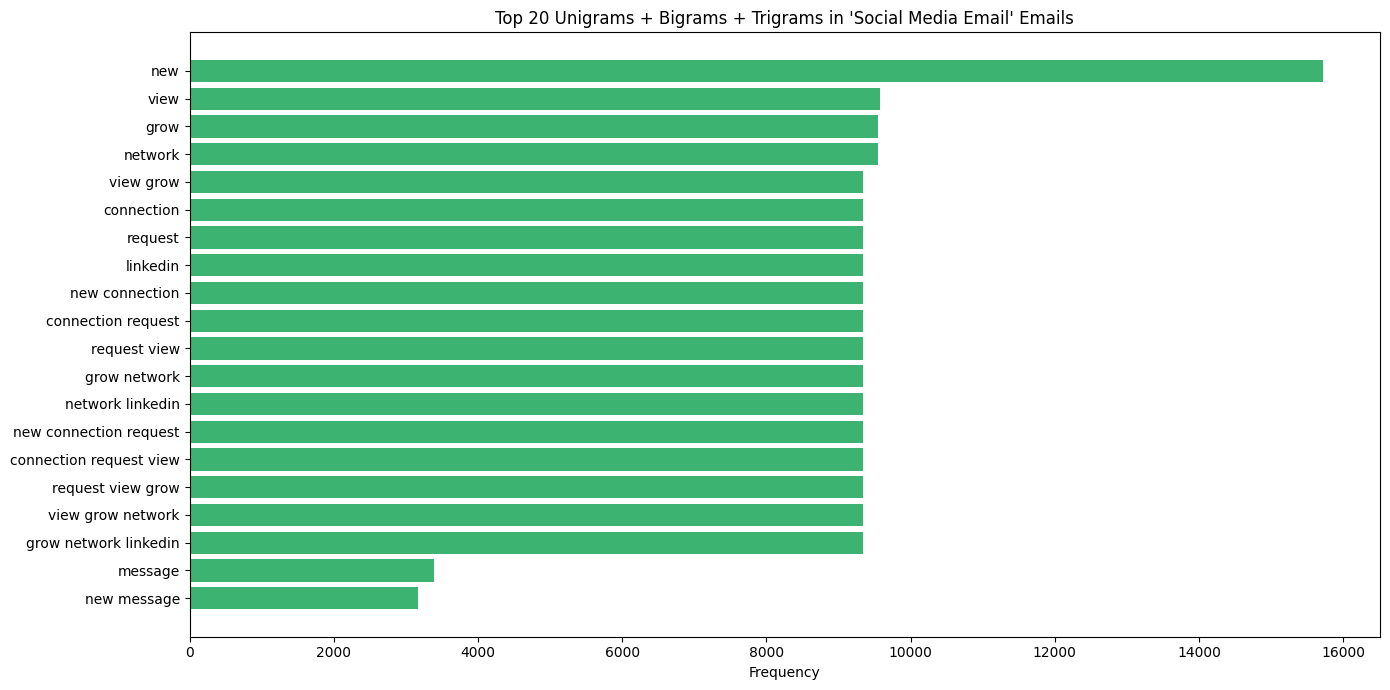

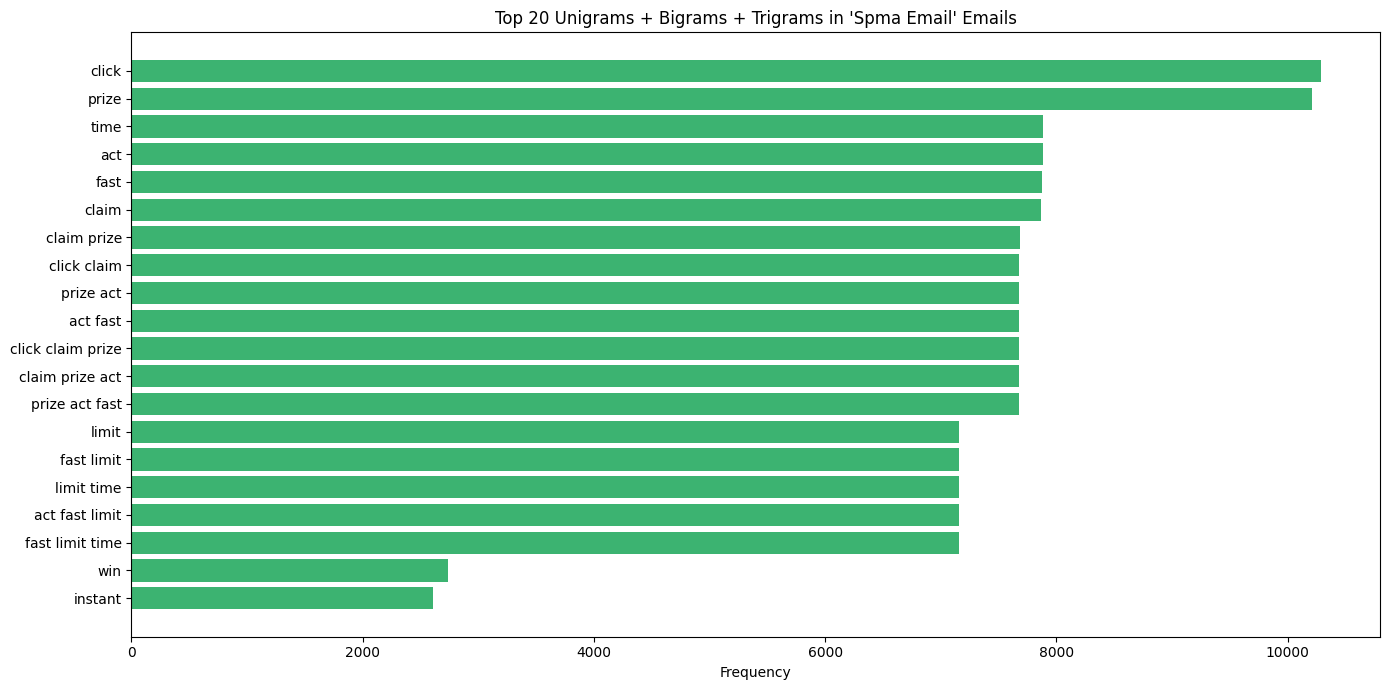

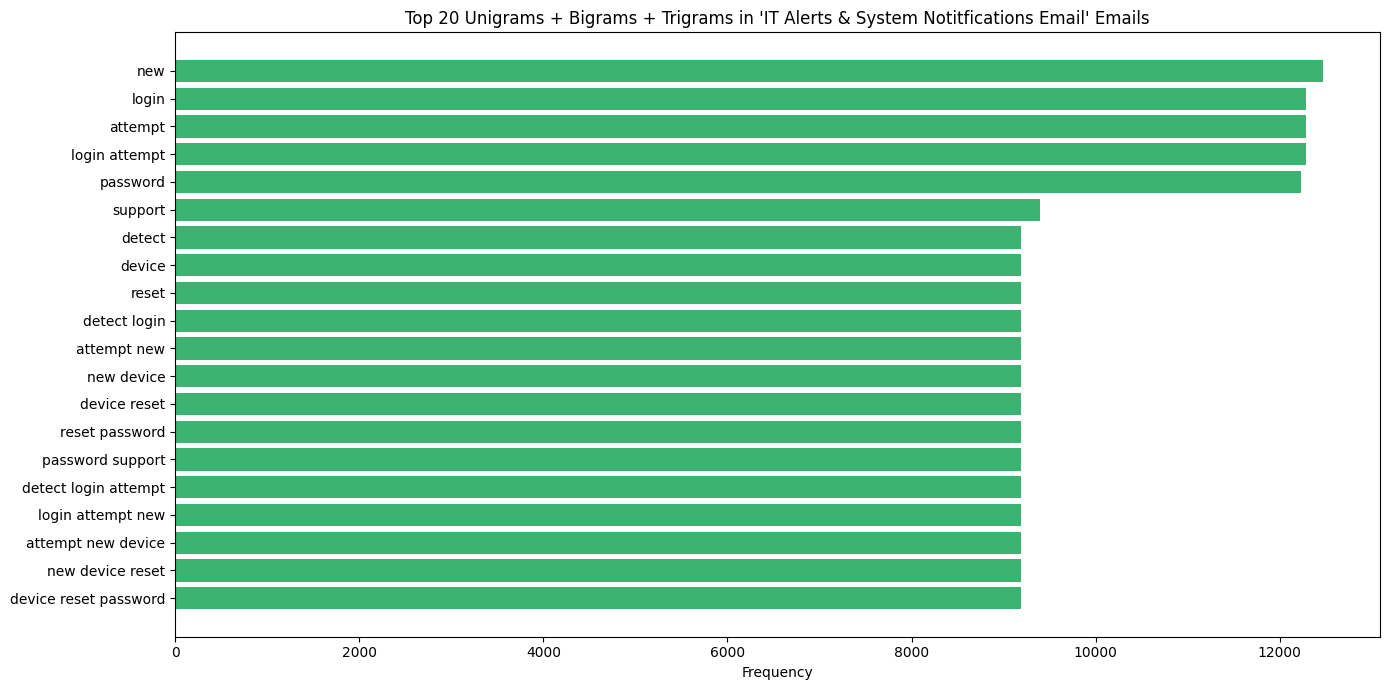

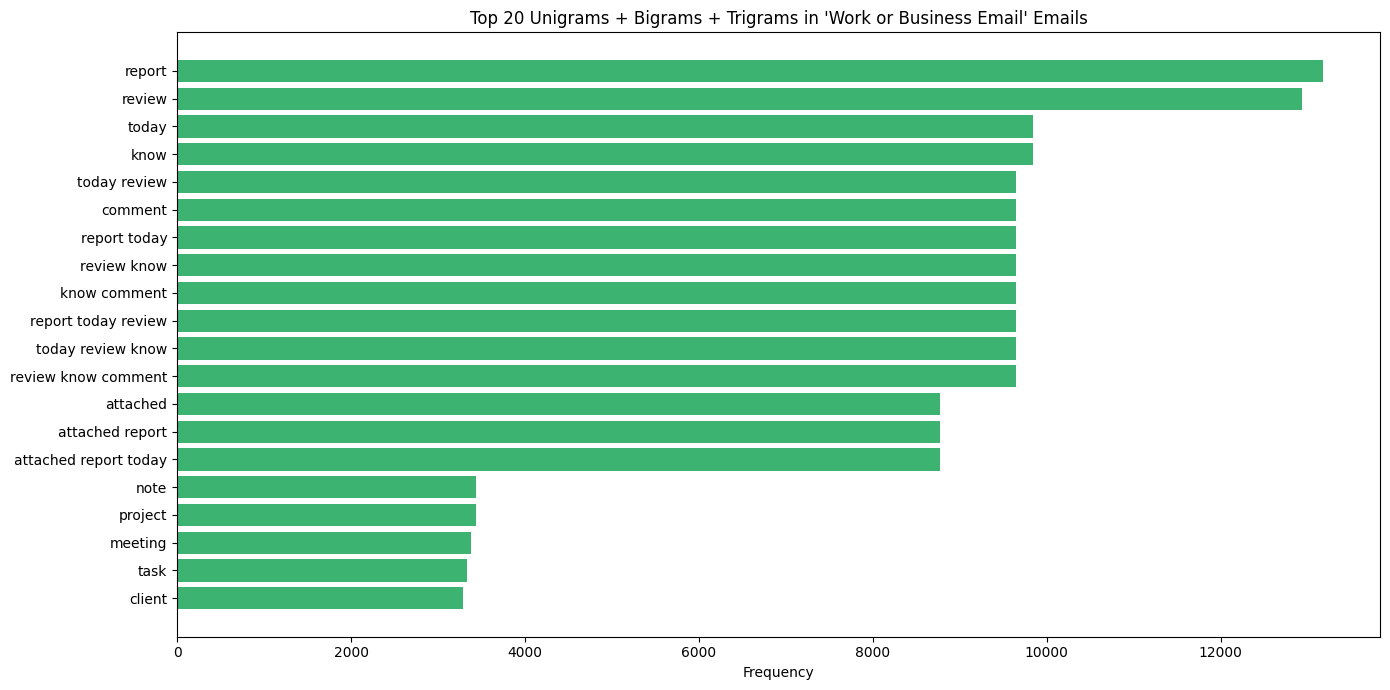

In [5]:
from collections import Counter
import matplotlib.pyplot as plt
from nltk.util import ngrams
from nltk.tokenize import word_tokenize
import nltk

nltk.download('punkt')

categories = email_data['Category'].unique()

for category in categories:
    category_emails = email_data[email_data['Category'] == category]
    text = " ".join(str(msg) for msg in category_emails['Combined_Text'].dropna())

    if not text.strip():
        continue

    tokens = word_tokenize(text.lower())

    # Generate n-grams
    unigrams = tokens
    bigrams = [' '.join(gram) for gram in ngrams(tokens, 2)]
    trigrams = [' '.join(gram) for gram in ngrams(tokens, 3)]

    # Combine all
    all_ngrams = unigrams + bigrams + trigrams
    ngram_freq = Counter(all_ngrams)
    top_ngrams = ngram_freq.most_common(20)

    if not top_ngrams:
        continue

    labels = [ngram for ngram, _ in top_ngrams]
    values = [freq for _, freq in top_ngrams]

    plt.figure(figsize=(14, 7))
    plt.barh(labels, values, color='mediumseagreen')
    plt.xlabel("Frequency")
    plt.title(f"Top 20 Unigrams + Bigrams + Trigrams in '{category}' Emails")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


In [2]:
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Initialize lemmatizer and stop words
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Lowercase
    text = text.lower()
    
    # Remove special characters and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Tokenize
    words = text.split()
    
    # Remove stop words and lemmatize
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    
    return ' '.join(words)

email_data['Cleaned_Subject'] = email_data['Cleaned_Subject'].apply(preprocess_text)
email_data['Cleaned_Message'] = email_data['Cleaned_Message'].apply(preprocess_text)
email_data['Combined_Text'] = email_data['Combined_Text'].apply(preprocess_text)

In [ ]:
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Initialize lemmatizer and stop words
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Add custom stop words
custom_stop_words = {'m', 'thank', 'dear', 'kindly', 'please', 'hi', 'let', 'team'}
stop_words = stop_words.union(custom_stop_words)

def preprocess_text(text):
    # Lowercase
    text = text.lower()
    
    # Normalize numerical values (replace with 'amount')
    text = re.sub(r'\b\d+\b', 'amount', text)  # Replace standalone numbers
    text = re.sub(r'rm\d+', 'amount', text)  # Replace RM values
    
    # Remove special characters
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Tokenize
    words = text.split()
    
    # Remove stop words and lemmatize
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    
    # Remove common phrases (example phrases to remove)
    common_phrases = ['thank tnb', 'payment rm', 'dear customer']
    for phrase in common_phrases:
        text = text.replace(phrase, '')
    
    return ' '.join(words)

# Assuming email_data is your DataFrame
# Preprocess the columns
email_data['Cleaned_Subject'] = email_data['Cleaned_Subject'].apply(preprocess_text)
email_data['Cleaned_Message'] = email_data['Cleaned_Message'].apply(preprocess_text)
email_data['Combined_Text'] = email_data['Combined_Text'].apply(preprocess_text)

In [ ]:
email_data.to_csv('cleaned_category_email_dataset.csv', index=False)

In [9]:
email_data.columns

Index(['Email ID', 'From', 'To', 'Date & Time', 'Subject', 'Message',
       'Category', 'Cleaned_Message', 'Cleaned_Subject', 'Combined_Text'],
      dtype='object')

In [10]:
email_data['Category'].value_counts()

Category
Work or Business Email                     9647
Promotions or Marketing Email              9601
Legal & Contractual Email                  9491
Personal Email                             9454
Meeting & Schedule                         9403
Internal Policies & HR Updates Email       9339
Social Media Email                         9337
Finance & Transaction Email                9290
IT Alerts & System Notitfications Email    9193
Spma Email                                 7676
Utilities Bill Email                       7569
Name: count, dtype: int64